In [1]:
# ============================================================
# STEP 1: INSTALL AND IMPORT LIBRARIES
# ============================================================

# nba_api lets us pull data directly from NBA.com
# pandas is for organizing and manipulating the data
!pip install nba_api pandas

import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamefinder


# ============================================================
# STEP 2: DEFINE FUNCTION TO PULL GAME DATA
# ============================================================

def get_nba_games(seasons):
    """
    Pulls all NBA regular season games for a list of seasons.
    Each game appears twice in the data — once per team.
    We'll use that later when building features.
    """
    all_games = []
    
    for season in seasons:
        print(f"Pulling data for {season}...")
        
        # Hit the NBA stats API for this season
        gamefinder = leaguegamefinder.LeagueGameFinder(
            season_nullable=season,
            league_id_nullable='00',         # 00 = NBA (not G League or WNBA)
            season_type_nullable='Regular Season'
        )
        
        # .get_data_frames()[0] returns the first (and only) table as a dataframe
        games = gamefinder.get_data_frames()[0]
        all_games.append(games)
        
        # Pause 1 second between calls so NBA.com doesn't rate limit us
        time.sleep(1)
    
    # Stack all seasons into one big dataframe
    df = pd.concat(all_games, ignore_index=True)
    return df


# ============================================================
# STEP 3: PULL THE DATA
# ============================================================

# Training + validation seasons (2020-21 through 2023-24)
seasons = ['2020-21', '2021-22', '2022-23', '2023-24']
df = get_nba_games(seasons)


# ============================================================
# STEP 4: PREVIEW THE DATA
# ============================================================

# Shape tells us how many rows (games) and columns (stats) we have
print(f"Shape: {df.shape}")

# Column names show us what data we pulled
print(f"\nColumns: {df.columns.tolist()}")

# First few rows so we can see what the data looks like
print(f"\nFirst 5 rows:")
df.head()

Pulling data for 2020-21...
Pulling data for 2021-22...
Pulling data for 2022-23...
Pulling data for 2023-24...
Shape: (9540, 28)

Columns: ['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS']

First 5 rows:


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22020,1610612763,MEM,Memphis Grizzlies,0022001070,2021-05-16,MEM @ GSW,L,241,101,...,0.789,12,27,39,25,12,5,12,21,-12.0
1,22020,1610612764,WAS,Washington Wizards,0022001080,2021-05-16,WAS vs. CHA,W,241,115,...,0.810,10,43,53,22,4,3,14,20,5.0
2,22020,1610612747,LAL,Los Angeles Lakers,0022001072,2021-05-16,LAL @ NOP,W,238,110,...,0.600,8,34,42,30,14,5,9,16,12.0
3,22020,1610612766,CHA,Charlotte Hornets,0022001080,2021-05-16,CHA @ WAS,L,240,110,...,0.917,10,32,42,25,8,5,11,15,-5.0
4,22020,1610612748,MIA,Miami Heat,0022001069,2021-05-16,MIA @ DET,W,241,120,...,0.650,6,33,39,32,11,5,10,19,13.0


In [2]:
# ============================================================
# STEP 5: MERGE GAMES INTO ONE ROW PER GAME
# ============================================================

# Right now each game is TWO rows — one per team
# We need to combine them into ONE row so we can compare teams head to head
# We do this by splitting the dataframe into home and away teams, then merging on GAME_ID

# ---- Split into home and away ----
# MATCHUP column tells us: "vs." = home team, "@" = away team
home = df[df['MATCHUP'].str.contains('vs.')].copy()
away = df[df['MATCHUP'].str.contains('@')].copy()

# ---- Rename columns so we know which team they belong to after merging ----
# Example: PTS becomes HOME_PTS and AWAY_PTS
home = home.add_prefix('HOME_')
away = away.add_prefix('AWAY_')

# After adding prefix, the GAME_ID columns are now HOME_GAME_ID and AWAY_GAME_ID
# We need to rename them back to GAME_ID so we can merge on them
home = home.rename(columns={'HOME_GAME_ID': 'GAME_ID'})
away = away.rename(columns={'AWAY_GAME_ID': 'GAME_ID'})

# ---- Merge home and away into one row per game ----
games = pd.merge(home, away, on='GAME_ID')
print(f"Games shape: {games.shape}")

# ---- Create our target variable: home team point differential ----
# This is what our model will try to predict
# Positive = home team won, Negative = away team won
games['POINT_DIFF'] = games['HOME_PTS'] - games['AWAY_PTS']

# Quick sanity check — average home team margin should be slightly positive
# Home teams historically win more and by more points
print(f"\nAverage home point differential: {games['POINT_DIFF'].mean():.2f}")
print(f"\nSample of key columns:")
games[['GAME_ID', 'HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'HOME_PTS', 'AWAY_PTS', 'POINT_DIFF']].head()

Games shape: (4770, 55)

Average home point differential: 1.86

Sample of key columns:


,GAME_ID,HOME_TEAM_ABBREVIATION,AWAY_TEAM_ABBREVIATION,HOME_PTS,AWAY_PTS,POINT_DIFF
0,0022001080,WAS,CHA,115,110,5
1,0022001075,PHI,ORL,128,117,11
2,0022001074,OKC,LAC,117,112,5
3,0022001066,ATL,HOU,124,95,29
4,0022001079,TOR,IND,113,125,-12


In [3]:
# ============================================================
# STEP 6: FEATURE ENGINEERING
# ============================================================

# We need to build features that we would KNOW before the game starts
# Raw box scores from the same game are useless — we can't see the future
# So we build ROLLING AVERAGES — how each team has been performing recently

# We'll use the ORIGINAL df (two rows per game) to calculate rolling stats per team
# Then merge those back onto our games dataframe

# ---- Sort by team and date so rolling averages go in the right direction ----
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values(['TEAM_ID', 'GAME_DATE']).reset_index(drop=True)

# ---- Calculate rolling stats per team ----
# .groupby('TEAM_ID') — do this separately for each team
# .rolling(10, min_periods=3) — look at last 10 games (need at least 3 to start)
# .mean() — average over that window
# .shift(1) — CRITICAL: shift by 1 so we don't include the current game in its own average

rolling = df.groupby('TEAM_ID')[['PTS', 'PTS']].rolling(10, min_periods=3).mean().shift(1)

# We need points scored (offense) and points allowed (defense) separately
# PTS = points scored by this team (offense)
# We get points allowed by looking at PLUS_MINUS: points allowed = PTS - PLUS_MINUS
df['PTS_ALLOWED'] = df['PTS'] - df['PLUS_MINUS']

# Now calculate rolling offense and defense for each team
df['ROLL_OFF'] = (
    df.groupby('TEAM_ID')['PTS']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

df['ROLL_DEF'] = (
    df.groupby('TEAM_ID')['PTS_ALLOWED']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

# ---- Calculate rest days per team ----
# How many days since this team last played?
# More rest = fresher legs, potentially better performance
df['DAYS_REST'] = (
    df.groupby('TEAM_ID')['GAME_DATE']
    .transform(lambda x: x.diff().dt.days)
)

# Cap rest days at 7 — anything more than a week is treated the same
df['DAYS_REST'] = df['DAYS_REST'].clip(upper=7)

# ---- Merge rolling stats back onto our one-row-per-game dataframe ----
# Pull just the columns we need for the merge
team_features = df[['GAME_ID', 'TEAM_ID', 'ROLL_OFF', 'ROLL_DEF', 'DAYS_REST']]

# Merge for home team
games = pd.merge(
    games,
    team_features.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_OFF': 'HOME_ROLL_OFF',
        'ROLL_DEF': 'HOME_ROLL_DEF',
        'DAYS_REST': 'HOME_DAYS_REST'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

# Merge for away team
games = pd.merge(
    games,
    team_features.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_OFF': 'AWAY_ROLL_OFF',
        'ROLL_DEF': 'AWAY_ROLL_DEF',
        'DAYS_REST': 'AWAY_DAYS_REST'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# ---- Drop rows where rolling averages couldn't be calculated ----
# Early season games won't have 3 prior games yet — we drop those
games = games.dropna(subset=['HOME_ROLL_OFF', 'HOME_ROLL_DEF', 'AWAY_ROLL_OFF', 'AWAY_ROLL_DEF'])

# ---- Quick sanity check ----
print(f"Games after feature engineering: {games.shape}")
print(f"\nSample features:")
games[['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'HOME_ROLL_OFF', 'HOME_ROLL_DEF', 'AWAY_ROLL_OFF', 'AWAY_ROLL_DEF', 'HOME_DAYS_REST', 'AWAY_DAYS_REST', 'POINT_DIFF']].head()

Games after feature engineering: (4722, 62)

Sample features:


,HOME_TEAM_ABBREVIATION,AWAY_TEAM_ABBREVIATION,HOME_ROLL_OFF,HOME_ROLL_DEF,AWAY_ROLL_OFF,AWAY_ROLL_DEF,HOME_DAYS_REST,AWAY_DAYS_REST,POINT_DIFF
0,WAS,CHA,127.4,121.2,107.3,112.6,2.0,1.0,5
1,PHI,ORL,114.4,102.4,101.1,115.3,2.0,2.0,11
2,OKC,LAC,101.9,121.3,108.3,105.1,2.0,2.0,5
3,ATL,HOU,112.6,113.3,117.1,126.4,3.0,2.0,29
4,TOR,IND,107.3,114.5,122.6,120.2,2.0,1.0,-12


In [4]:
# ============================================================
# STEP 7: TRAIN THE MODEL
# ============================================================

# We'll use XGBoost — a powerful machine learning algorithm
# that works really well with tabular data like this
# It's widely used in quant finance and will look great on your resume

!pip install xgboost

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np

# ============================================================
# STEP 7A: SPLIT DATA INTO TRAIN AND VALIDATION
# ============================================================

# Convert GAME_DATE to datetime so we can filter by season
games['HOME_GAME_DATE'] = pd.to_datetime(games['HOME_GAME_DATE'])

# Training set: 2020-21 through 2022-23
# Validation set: 2023-24
# We're holding 2024-25 completely aside for the final backtest

train = games[games['HOME_GAME_DATE'] < '2023-10-01'].copy()
val   = games[games['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games:   {len(train)}")
print(f"Validation games: {len(val)}")

# ============================================================
# STEP 7B: DEFINE FEATURES AND TARGET
# ============================================================

# These are the inputs the model will use to make predictions
# All things we know BEFORE the game tips off
features = [
    'HOME_ROLL_OFF',    # home team's recent scoring average
    'HOME_ROLL_DEF',    # home team's recent points allowed average
    'AWAY_ROLL_OFF',    # away team's recent scoring average
    'AWAY_ROLL_DEF',    # away team's recent points allowed average
    'HOME_DAYS_REST',   # rest days for home team
    'AWAY_DAYS_REST'    # rest days for away team
]

# This is what we're trying to predict — home team point differential
target = 'POINT_DIFF'

X_train = train[features]
y_train = train[target]

X_val = val[features]
y_val = val[target]

# ============================================================
# STEP 7C: TRAIN THE MODEL
# ============================================================

model = xgb.XGBRegressor(
    n_estimators=100,       # number of trees to build
    learning_rate=0.05,     # how much each tree contributes
    max_depth=4,            # how deep each tree can go
    random_state=42         # makes results reproducible
)

model.fit(X_train, y_train)
print("\nModel trained successfully")

# ============================================================
# STEP 7D: EVALUATE ON VALIDATION SET
# ============================================================

# Generate predictions on the validation set (2023-24 season)
val_preds = model.predict(X_val)

# Mean Absolute Error — on average how many points off are our predictions?
mae = mean_absolute_error(y_val, val_preds)
print(f"\nValidation MAE: {mae:.2f} points")

# Baseline MAE — what if we just predicted 0 (pick em) every game?
# Our model should beat this
baseline_mae = mean_absolute_error(y_val, np.zeros(len(y_val)))
print(f"Baseline MAE (always predict 0): {baseline_mae:.2f} points")

# ============================================================
# STEP 7E: FEATURE IMPORTANCE
# ============================================================

# This tells us which features the model leaned on most
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature importance:")
print(importance)

Training games:   3492
Validation games: 1230

Model trained successfully

Validation MAE: 11.45 points
Baseline MAE (always predict 0): 12.58 points

Feature importance:
          feature  importance
1   HOME_ROLL_DEF    0.217081
0   HOME_ROLL_OFF    0.205652
3   AWAY_ROLL_DEF    0.174099
2   AWAY_ROLL_OFF    0.164310
4  HOME_DAYS_REST    0.120026
5  AWAY_DAYS_REST    0.118832


In [5]:
# ============================================================
# STEP 8: PULL 2024-25 SEASON DATA (OUR BACKTEST SEASON)
# ============================================================

print("Pulling 2024-25 season data...")

gamefinder = leaguegamefinder.LeagueGameFinder(
    season_nullable='2024-25',
    league_id_nullable='00',
    season_type_nullable='Regular Season'
)

df_2425 = gamefinder.get_data_frames()[0]
print(f"Raw rows pulled: {df_2425.shape}")

# ============================================================
# STEP 8B: APPLY CLEANING STEPS
# ============================================================

df_2425['GAME_DATE'] = pd.to_datetime(df_2425['GAME_DATE'])
df_2425 = df_2425.sort_values(['TEAM_ID', 'GAME_DATE']).reset_index(drop=True)

df_2425['PTS_ALLOWED'] = df_2425['PTS'] - df_2425['PLUS_MINUS']

df_2425['ROLL_OFF'] = (
    df_2425.groupby('TEAM_ID')['PTS']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

df_2425['ROLL_DEF'] = (
    df_2425.groupby('TEAM_ID')['PTS_ALLOWED']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

df_2425['DAYS_REST'] = (
    df_2425.groupby('TEAM_ID')['GAME_DATE']
    .transform(lambda x: x.diff().dt.days)
)
df_2425['DAYS_REST'] = df_2425['DAYS_REST'].clip(upper=7)

# ============================================================
# STEP 8C: MERGE INTO ONE ROW PER GAME
# ============================================================

# Split into home and away — keep ONLY the columns we need before adding prefix
# This prevents duplicate rolling columns after the merge
cols_to_keep = ['GAME_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'GAME_DATE', 
                'MATCHUP', 'WL', 'PTS', 'PLUS_MINUS']

home_2425 = df_2425[df_2425['MATCHUP'].str.contains('vs.')][cols_to_keep].copy()
away_2425 = df_2425[df_2425['MATCHUP'].str.contains('@')][cols_to_keep].copy()

home_2425 = home_2425.add_prefix('HOME_')
away_2425 = away_2425.add_prefix('AWAY_')

home_2425 = home_2425.rename(columns={'HOME_GAME_ID': 'GAME_ID'})
away_2425 = away_2425.rename(columns={'AWAY_GAME_ID': 'GAME_ID'})

games_2425 = pd.merge(home_2425, away_2425, on='GAME_ID')
games_2425['POINT_DIFF'] = games_2425['HOME_PTS'] - games_2425['AWAY_PTS']

# ============================================================
# STEP 8D: MERGE ROLLING FEATURES SEPARATELY
# ============================================================

team_features_2425 = df_2425[['GAME_ID', 'TEAM_ID', 'ROLL_OFF', 'ROLL_DEF', 'DAYS_REST']].copy()

# Merge home team features
games_2425 = pd.merge(
    games_2425,
    team_features_2425.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_OFF': 'HOME_ROLL_OFF',
        'ROLL_DEF': 'HOME_ROLL_DEF',
        'DAYS_REST': 'HOME_DAYS_REST'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

# Merge away team features
games_2425 = pd.merge(
    games_2425,
    team_features_2425.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_OFF': 'AWAY_ROLL_OFF',
        'ROLL_DEF': 'AWAY_ROLL_DEF',
        'DAYS_REST': 'AWAY_DAYS_REST'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# Drop rows without enough prior games
games_2425 = games_2425.dropna(subset=['HOME_ROLL_OFF', 'HOME_ROLL_DEF', 'AWAY_ROLL_OFF', 'AWAY_ROLL_DEF'])

print(f"\n2024-25 games ready for backtest: {len(games_2425)}")
print(f"\nSample:")
games_2425[['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'HOME_ROLL_OFF', 'AWAY_ROLL_OFF', 'POINT_DIFF']].head()


Pulling 2024-25 season data...
Raw rows pulled: (2460, 28)

2024-25 games ready for backtest: 1177

Sample:


,HOME_TEAM_ABBREVIATION,AWAY_TEAM_ABBREVIATION,HOME_ROLL_OFF,AWAY_ROLL_OFF,POINT_DIFF
3,ATL,SAC,117.600000,116.500000,-8
4,ATL,BOS,118.428571,123.714286,-30
5,ATL,NYK,115.250000,112.833333,5
6,ATL,CHI,116.400000,113.666667,-12
7,ATL,WAS,114.900000,110.200000,12


In [6]:
# ============================================================
# STEP 9: LOAD BETTING DATA
# ============================================================

# Load the betting data from your Downloads folder
betting = pd.read_csv('/Users/jkramer24/Downloads/nba_2008-2025.csv')

print(f"Shape: {betting.shape}")
print(f"\nColumns: {betting.columns.tolist()}")
print(f"\nFirst 5 rows:")
betting.head()

Shape: (23118, 27)

Columns: ['season', 'date', 'regular', 'playoffs', 'away', 'home', 'score_away', 'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away', 'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home', 'whos_favored', 'spread', 'total', 'moneyline_away', 'moneyline_home', 'h2_spread', 'h2_total', 'id_spread', 'id_total']

First 5 rows:


,season,date,regular,playoffs,away,home,score_away,score_home,q1_away,q2_away,...,ot_home,whos_favored,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
0,2008,2007-10-30,True,False,por,sa,97,106,26,23,...,0,home,13.0,189.5,900.0,-1400.0,5.0,95.0,0.0,1
1,2008,2007-10-30,True,False,utah,gs,117,96,28,34,...,0,home,1.0,212.0,100.0,-120.0,3.0,105.5,0.0,1
2,2008,2007-10-30,True,False,hou,lal,95,93,16,27,...,0,away,5.0,199.0,-230.0,190.0,3.0,99.0,0.0,0
3,2008,2007-10-31,True,False,phi,tor,97,106,22,28,...,0,home,6.5,191.0,255.0,-305.0,2.0,96.5,1.0,1
4,2008,2007-10-31,True,False,wsh,ind,110,119,23,22,...,16,away,1.5,203.5,-125.0,105.0,1.0,105.0,0.0,1


In [7]:
# ============================================================
# STEP 9B: FILTER TO 2024-25 SEASON AND INSPECT
# ============================================================

# Filter to just the 2024-25 season
betting_2425 = betting[betting['season'] == 2025].copy()

print(f"2024-25 betting rows: {len(betting_2425)}")
print(f"\nUnique away team abbreviations:")
print(sorted(betting_2425['away'].unique()))
print(f"\nSample:")
betting_2425[['date', 'home', 'away', 'spread', 'whos_favored', 'score_home', 'score_away']].head(10)


2024-25 betting rows: 1321

Unique away team abbreviations:
['atl', 'bkn', 'bos', 'cha', 'chi', 'cle', 'dal', 'den', 'det', 'gs', 'hou', 'ind', 'lac', 'lal', 'mem', 'mia', 'mil', 'min', 'no', 'ny', 'okc', 'orl', 'phi', 'phx', 'por', 'sa', 'sac', 'tor', 'utah', 'wsh']

Sample:


,date,home,away,spread,whos_favored,score_home,score_away
21797,2024-10-22,lal,min,1.5,away,110,103
21798,2024-10-22,bos,ny,5.5,home,132,109
21799,2024-10-23,no,chi,5.5,home,123,111
21800,2024-10-23,mia,orl,1.5,home,97,116
21801,2024-10-23,phi,mil,4.5,away,109,124
21802,2024-10-23,atl,bkn,7.5,home,120,116
21803,2024-10-23,utah,mem,2.5,away,124,126
21804,2024-10-23,det,ind,5.5,away,109,115
21805,2024-10-23,por,gs,7.5,away,104,140
21806,2024-10-23,lac,phx,4.5,away,113,116


In [8]:
# ============================================================
# STEP 10: MAP TEAM ABBREVIATIONS
# ============================================================

# The betting file uses short lowercase abbreviations
# The NBA API uses official 3-letter uppercase abbreviations
# We need to map them so we can merge the two datasets

abbrev_map = {
    'atl': 'ATL', 'bkn': 'BKN', 'bos': 'BOS', 'cha': 'CHA',
    'chi': 'CHI', 'cle': 'CLE', 'dal': 'DAL', 'den': 'DEN',
    'det': 'DET', 'gs':  'GSW', 'hou': 'HOU', 'ind': 'IND',
    'lac': 'LAC', 'lal': 'LAL', 'mem': 'MEM', 'mia': 'MIA',
    'mil': 'MIL', 'min': 'MIN', 'no':  'NOP', 'ny':  'NYK',
    'okc': 'OKC', 'orl': 'ORL', 'phi': 'PHI', 'phx': 'PHX',
    'por': 'POR', 'sa':  'SAS', 'sac': 'SAC', 'tor': 'TOR',
    'utah':'UTA', 'wsh': 'WAS'
}

# Apply the mapping to home and away columns
betting_2425 = betting_2425.copy()
betting_2425['home'] = betting_2425['home'].map(abbrev_map)
betting_2425['away'] = betting_2425['away'].map(abbrev_map)

# Convert date to datetime so we can merge on it
betting_2425['date'] = pd.to_datetime(betting_2425['date'])

# Sanity check
print("Any unmapped teams:", betting_2425['home'].isna().sum())
print("\nSample after mapping:")
betting_2425[['date', 'home', 'away', 'spread', 'whos_favored']].head(5)

Any unmapped teams: 0

Sample after mapping:


,date,home,away,spread,whos_favored
21797,2024-10-22,LAL,MIN,1.5,away
21798,2024-10-22,BOS,NYK,5.5,home
21799,2024-10-23,NOP,CHI,5.5,home
21800,2024-10-23,MIA,ORL,1.5,home
21801,2024-10-23,PHI,MIL,4.5,away


In [9]:
# ============================================================
# STEP 10B: FILTER BETTING DATA TO REGULAR SEASON ONLY
# ============================================================

# Our model was trained on regular season data only
# Playoff basketball is different so we exclude it to keep things consistent
betting_2425 = betting_2425[betting_2425['regular'] == True].copy()

print(f"Regular season games only: {len(betting_2425)}")

# ============================================================
# STEP 11: MERGE BETTING LINES WITH GAME DATA
# ============================================================

# Join on date + home team + away team
# Gives us one row per game with both our features AND the Vegas spread
games_2425['HOME_GAME_DATE'] = pd.to_datetime(games_2425['HOME_GAME_DATE'])

merged = pd.merge(
    games_2425,
    betting_2425[['date', 'home', 'away', 'spread', 'whos_favored']],
    left_on=['HOME_GAME_DATE', 'HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION'],
    right_on=['date', 'home', 'away'],
    how='inner'
)

print(f"Games successfully merged with betting lines: {len(merged)}")

# ============================================================
# STEP 12: RUN MODEL PREDICTIONS ON 2024-25
# ============================================================

# Use the same 6 features we trained on
X_backtest = merged[features]

# Generate our model's predicted point differential for each game
merged['MODEL_PRED'] = model.predict(X_backtest)

# ============================================================
# STEP 13: CREATE THE SIGNAL
# ============================================================

# Convert Vegas spread to home team perspective
# If home team is favored: spread is negative (they must win by X)
# If away team is favored: spread is positive for the home team
merged['VEGAS_LINE'] = merged.apply(
    lambda row: -row['spread'] if row['whos_favored'] == 'home' else row['spread'],
    axis=1
)

# Signal = our prediction minus the Vegas line
# Positive = we think home team will do better than Vegas says
# Negative = we think away team will do better than Vegas says
merged['SIGNAL'] = merged['MODEL_PRED'] - merged['VEGAS_LINE']

print(f"\nSignal summary:")
print(merged['SIGNAL'].describe())
print(f"\nSample:")
merged[['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'VEGAS_LINE', 'MODEL_PRED', 'SIGNAL', 'POINT_DIFF']].head(10)

Regular season games only: 1230
Games successfully merged with betting lines: 1177

Signal summary:
count    1177.000000
mean        3.989685
std        12.087252
min       -33.587341
25%        -4.570533
50%         5.050126
75%        12.540850
max        44.381168
Name: SIGNAL, dtype: float64

Sample:


,HOME_TEAM_ABBREVIATION,AWAY_TEAM_ABBREVIATION,VEGAS_LINE,MODEL_PRED,SIGNAL,POINT_DIFF
0,ATL,SAC,6.5,-3.147629,-9.647629,-8
1,ATL,BOS,10.5,-2.016081,-12.516081,-30
2,ATL,NYK,7.5,-3.836926,-11.336926,5
3,ATL,CHI,-2.5,0.728830,3.228830,-12
4,ATL,WAS,-9.5,4.145508,13.645508,12
5,ATL,DAL,-2.5,-1.244146,1.255854,-10
6,ATL,CLE,5.5,-2.476846,-7.976846,16
7,ATL,NOP,-9.5,34.881168,44.381168,12
8,ATL,LAL,-3.5,7.500786,11.000786,2
9,ATL,DEN,-0.5,2.427435,2.927435,-30


In [10]:
# ============================================================
# STEP 14: RUN THE BACKTEST
# ============================================================

# This is the moment of truth — we simulate betting every time
# our model disagrees with Vegas by more than a threshold
# and see how much money we would have made or lost

# Standard bet size — $100 per game
BET_SIZE = 100

# In sports betting you pay a "vig" (commission) to the book
# Standard vig means you bet $110 to win $100
# So if you win you profit $100, if you lose you lose $110
WIN_PAYOUT = 100
LOSS_COST = 110

# ---- Define our betting rule ----
# We only bet when our model disagrees with Vegas by more than THRESHOLD points
# We'll test multiple thresholds to find where our model has the most edge
results = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    
    # Find games where signal is strong enough to bet
    bet_games = merged[abs(merged['SIGNAL']) >= threshold].copy()
    
    if len(bet_games) == 0:
        continue
    
    # Determine if we won each bet
    # If signal is positive, we think home team beats Vegas — bet home
    # If signal is negative, we think away team beats Vegas — bet away
    def did_we_win(row):
        if row['SIGNAL'] > 0:
            # We bet home team to beat the Vegas line
            # We win if actual point diff > Vegas line (but Vegas line is from away perspective)
            return row['POINT_DIFF'] > -row['VEGAS_LINE']
        else:
            # We bet away team to beat the Vegas line
            return row['POINT_DIFF'] < -row['VEGAS_LINE']
    
    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    
    # Calculate P&L
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100
    
    results.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

results_df = pd.DataFrame(results)
print("Backtest Results:")
print(results_df.to_string(index=False))

Backtest Results:
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   995   503     492    50.6% $-3,820
         4   938   480     458    51.2% $-2,380
         5   879   454     425    51.6% $-1,350
         6   808   423     385    52.4%    $-50
         7   739   391     348    52.9%    $820
         8   678   360     318    53.1%  $1,020
        10   545   285     260    52.3%   $-100


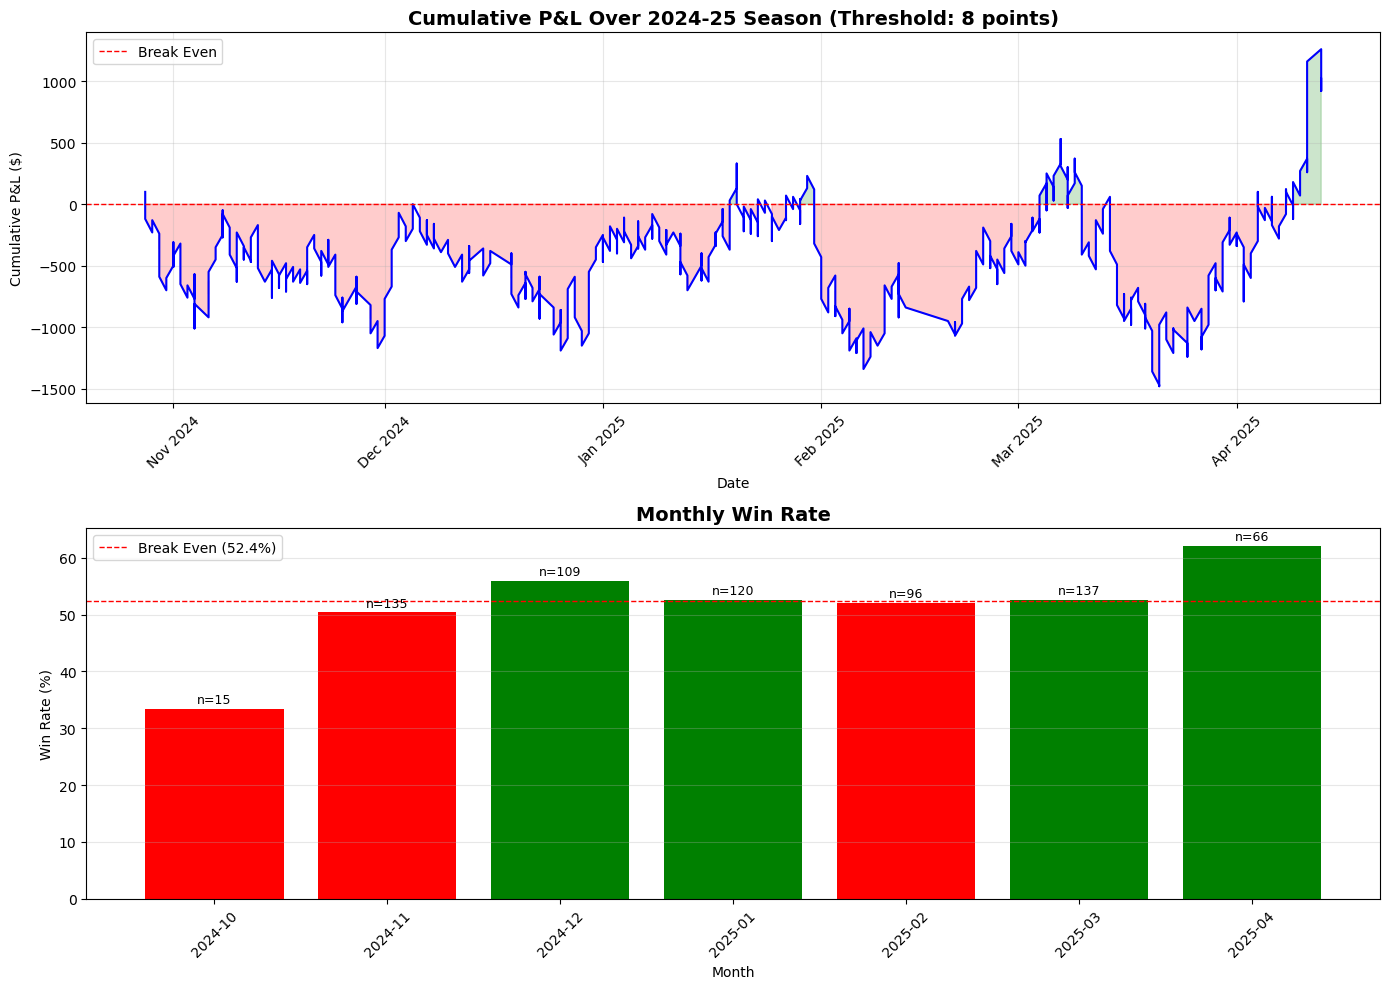

Chart saved to Downloads folder


In [11]:
# ============================================================
# STEP 15: VISUALIZE P&L OVER TIME
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use threshold 8 since that was our best performing threshold
BEST_THRESHOLD = 8

# Get the games we would have bet on
bet_games = merged[abs(merged['SIGNAL']) >= BEST_THRESHOLD].copy()

# Sort by date so we can track P&L chronologically
bet_games = bet_games.sort_values('HOME_GAME_DATE').reset_index(drop=True)

# Calculate win/loss for each bet
bet_games['WON'] = bet_games.apply(did_we_win, axis=1)

# Calculate running P&L — cumulative sum of wins and losses over the season
bet_games['GAME_PNL'] = bet_games['WON'].apply(lambda x: WIN_PAYOUT if x else -LOSS_COST)
bet_games['CUMULATIVE_PNL'] = bet_games['GAME_PNL'].cumsum()

# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Chart 1: Cumulative P&L over the season ---
axes[0].plot(bet_games['HOME_GAME_DATE'], bet_games['CUMULATIVE_PNL'],
             color='blue', linewidth=1.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break Even')
axes[0].fill_between(bet_games['HOME_GAME_DATE'], bet_games['CUMULATIVE_PNL'], 0,
                     where=bet_games['CUMULATIVE_PNL'] >= 0, alpha=0.2, color='green')
axes[0].fill_between(bet_games['HOME_GAME_DATE'], bet_games['CUMULATIVE_PNL'], 0,
                     where=bet_games['CUMULATIVE_PNL'] < 0, alpha=0.2, color='red')
axes[0].set_title(f'Cumulative P&L Over 2024-25 Season (Threshold: {BEST_THRESHOLD} points)', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
axes[0].grid(True, alpha=0.3)

# --- Chart 2: Win rate by month ---
bet_games['MONTH'] = bet_games['HOME_GAME_DATE'].dt.to_period('M')
monthly = bet_games.groupby('MONTH').agg(
    win_rate=('WON', 'mean'),
    num_bets=('WON', 'count')
).reset_index()
monthly['MONTH_STR'] = monthly['MONTH'].astype(str)

bars = axes[1].bar(monthly['MONTH_STR'], monthly['win_rate'] * 100,
                   color=['green' if x > 52.4 else 'red' for x in monthly['win_rate'] * 100])
axes[1].axhline(y=52.4, color='red', linestyle='--', linewidth=1, label='Break Even (52.4%)')
axes[1].set_title('Monthly Win Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Win Rate (%)')
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Add bet count labels on bars
for bar, row in zip(bars, monthly.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'n={row.num_bets}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/jkramer24/Downloads/nba_backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Downloads folder")

In [12]:
# ============================================================
# STEP 16: PULL 2025-26 SEASON DATA
# ============================================================

print("Pulling 2025-26 season data...")

gamefinder_2526 = leaguegamefinder.LeagueGameFinder(
    season_nullable='2025-26',
    league_id_nullable='00',
    season_type_nullable='Regular Season'
)

df_2526 = gamefinder_2526.get_data_frames()[0]
print(f"Raw rows pulled: {df_2526.shape}")
print(f"\nSample:")
df_2526[['TEAM_ABBREVIATION', 'GAME_DATE', 'MATCHUP', 'WL', 'PTS', 'PLUS_MINUS']].head()

Pulling 2025-26 season data...
Raw rows pulled: (2460, 28)

Sample:


,TEAM_ABBREVIATION,GAME_DATE,MATCHUP,WL,PTS,PLUS_MINUS
0,MEM,2026-04-12,MEM @ HOU,L,101,-31.0
1,PHX,2026-04-12,PHX @ OKC,W,135,32.0
2,MIN,2026-04-12,MIN vs. NOP,W,132,6.0
3,DAL,2026-04-12,DAL vs. CHI,W,149,21.0
4,ATL,2026-04-12,ATL @ MIA,L,117,-26.0


In [13]:
# ============================================================
# STEP 17: ENGINEER BETTER FEATURES
# ============================================================

# We're going back to the original df (training data 2020-24)
# and adding more features before retraining the model
# Goal: more consistent returns, not just higher total profit

# ---- Feature 1: Back-to-back flag ----
# A team playing on 0 or 1 days rest is on a back-to-back
# This is one of the strongest known edges in NBA betting
df['IS_B2B'] = (df['DAYS_REST'] <= 1).astype(int)

# ---- Feature 2: Short rolling window (last 5 games) ----
# Captures recent hot/cold streaks better than 10 game window
df['ROLL_OFF_5'] = (
    df.groupby('TEAM_ID')['PTS']
    .transform(lambda x: x.rolling(5, min_periods=2).mean().shift(1))
)

df['ROLL_DEF_5'] = (
    df.groupby('TEAM_ID')['PTS_ALLOWED']
    .transform(lambda x: x.rolling(5, min_periods=2).mean().shift(1))
)

# ---- Feature 3: Season win percentage ----
# Overall team quality — cumulative wins divided by games played so far
df['WIN'] = (df['WL'] == 'W').astype(int)
df['SEASON_WIN_PCT'] = (
    df.groupby(['TEAM_ID', 'SEASON_ID'])['WIN']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# ---- Feature 4: Rest advantage ----
# We'll calculate this after merging home and away
# For now just make sure DAYS_REST is clean
df['DAYS_REST'] = df['DAYS_REST'].fillna(3)  # fill first game of season with average rest

# ---- Rebuild team features with new columns ----
team_features_new = df[[
    'GAME_ID', 'TEAM_ID', 
    'ROLL_OFF', 'ROLL_DEF',           # original 10-game rolling
    'ROLL_OFF_5', 'ROLL_DEF_5',       # new 5-game rolling
    'DAYS_REST', 'IS_B2B',            # rest features
    'SEASON_WIN_PCT'                   # overall team quality
]].copy()

print("New team features built successfully")
print(f"\nSample:")
team_features_new[['TEAM_ID', 'ROLL_OFF', 'ROLL_OFF_5', 'DAYS_REST', 'IS_B2B', 'SEASON_WIN_PCT']].head()

New team features built successfully

Sample:


,TEAM_ID,ROLL_OFF,ROLL_OFF_5,DAYS_REST,IS_B2B,SEASON_WIN_PCT
0,1610612737,NaN,NaN,3.0,0,NaN
1,1610612737,NaN,NaN,3.0,0,1.00
2,1610612737,NaN,123.000000,2.0,0,1.00
3,1610612737,124.666667,124.666667,2.0,0,1.00
4,1610612737,128.750000,128.750000,2.0,0,0.75


In [14]:
# ============================================================
# STEP 18: MERGE NEW FEATURES ONTO GAMES DATAFRAME
# ============================================================

# Start fresh from the original merged games dataframe
# We need to re-merge with the new expanded feature set

# Merge home team new features
games_new = pd.merge(
    games[['GAME_ID', 'HOME_GAME_DATE', 'HOME_TEAM_ID', 'HOME_TEAM_ABBREVIATION',
           'AWAY_TEAM_ID', 'AWAY_TEAM_ABBREVIATION', 'HOME_PTS', 'AWAY_PTS', 'POINT_DIFF']],
    team_features_new.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_OFF': 'HOME_ROLL_OFF',
        'ROLL_DEF': 'HOME_ROLL_DEF',
        'ROLL_OFF_5': 'HOME_ROLL_OFF_5',
        'ROLL_DEF_5': 'HOME_ROLL_DEF_5',
        'DAYS_REST': 'HOME_DAYS_REST',
        'IS_B2B': 'HOME_IS_B2B',
        'SEASON_WIN_PCT': 'HOME_WIN_PCT'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

# Merge away team new features
games_new = pd.merge(
    games_new,
    team_features_new.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_OFF': 'AWAY_ROLL_OFF',
        'ROLL_DEF': 'AWAY_ROLL_DEF',
        'ROLL_OFF_5': 'AWAY_ROLL_OFF_5',
        'ROLL_DEF_5': 'AWAY_ROLL_DEF_5',
        'DAYS_REST': 'AWAY_DAYS_REST',
        'IS_B2B': 'AWAY_IS_B2B',
        'SEASON_WIN_PCT': 'AWAY_WIN_PCT'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# ---- Feature 5: Rest advantage ----
# Positive = home team has more rest
# Negative = away team has more rest
games_new['REST_ADVANTAGE'] = games_new['HOME_DAYS_REST'] - games_new['AWAY_DAYS_REST']

# ---- Feature 6: Win pct advantage ----
# How much better is the home team overall vs away team
games_new['WIN_PCT_ADVANTAGE'] = games_new['HOME_WIN_PCT'] - games_new['AWAY_WIN_PCT']

# Drop rows with NaN features
games_new = games_new.dropna(subset=[
    'HOME_ROLL_OFF', 'HOME_ROLL_DEF', 'AWAY_ROLL_OFF', 'AWAY_ROLL_DEF',
    'HOME_ROLL_OFF_5', 'HOME_ROLL_DEF_5', 'AWAY_ROLL_OFF_5', 'AWAY_ROLL_DEF_5',
    'HOME_WIN_PCT', 'AWAY_WIN_PCT'
])

print(f"Games with new features: {len(games_new)}")
print(f"\nSample:")
games_new[['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 
           'HOME_ROLL_OFF', 'HOME_ROLL_OFF_5', 'HOME_IS_B2B', 
           'REST_ADVANTAGE', 'WIN_PCT_ADVANTAGE', 'POINT_DIFF']].head()

Games with new features: 4675

Sample:


,HOME_TEAM_ABBREVIATION,AWAY_TEAM_ABBREVIATION,HOME_ROLL_OFF,HOME_ROLL_OFF_5,HOME_IS_B2B,REST_ADVANTAGE,WIN_PCT_ADVANTAGE,POINT_DIFF
0,WAS,CHA,127.4,124.8,0,1.0,0.000000,5
1,PHI,ORL,114.4,107.4,0,0.0,0.380282,11
2,OKC,LAC,101.9,98.2,0,0.0,-0.366197,5
3,ATL,HOU,112.6,124.4,0,1.0,0.323944,29
4,TOR,IND,107.3,107.2,0,1.0,-0.084507,-12


In [15]:
# ============================================================
# STEP 19: RETRAIN MODEL WITH NEW FEATURES
# ============================================================

# Define our expanded feature set — up from 6 to 13 features
features_new = [
    'HOME_ROLL_OFF',        # home 10-game offensive average
    'HOME_ROLL_DEF',        # home 10-game defensive average
    'AWAY_ROLL_OFF',        # away 10-game offensive average
    'AWAY_ROLL_DEF',        # away 10-game defensive average
    'HOME_ROLL_OFF_5',      # home 5-game offensive average (recent form)
    'HOME_ROLL_DEF_5',      # home 5-game defensive average (recent form)
    'AWAY_ROLL_OFF_5',      # away 5-game offensive average (recent form)
    'AWAY_ROLL_DEF_5',      # away 5-game defensive average (recent form)
    'HOME_DAYS_REST',       # home team rest days
    'AWAY_DAYS_REST',       # away team rest days
    'HOME_IS_B2B',          # home team on back-to-back?
    'AWAY_IS_B2B',          # away team on back-to-back?
    'REST_ADVANTAGE',       # rest days difference
    'WIN_PCT_ADVANTAGE'     # season win pct difference
]

# Same train/val split as before
# Train: 2020-21 through 2022-23
# Validation: 2023-24
games_new['HOME_GAME_DATE'] = pd.to_datetime(games_new['HOME_GAME_DATE'])
train_new = games_new[games_new['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_new   = games_new[games_new['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games:   {len(train_new)}")
print(f"Validation games: {len(val_new)}")

X_train_new = train_new[features_new]
y_train_new = train_new['POINT_DIFF']

X_val_new = val_new[features_new]
y_val_new = val_new['POINT_DIFF']

# Train the new model
model_new = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_new.fit(X_train_new, y_train_new)
print("\nNew model trained successfully")

# Evaluate
val_preds_new = model_new.predict(X_val_new)
mae_new = mean_absolute_error(y_val_new, val_preds_new)
print(f"\nNew model Validation MAE: {mae_new:.2f} points")
print(f"Old model Validation MAE: 11.45 points")
print(f"Improvement: {11.45 - mae_new:.2f} points")

# Feature importance
importance_new = pd.DataFrame({
    'feature': features_new,
    'importance': model_new.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature importance:")
print(importance_new.to_string(index=False))

Training games:   3460
Validation games: 1215

New model trained successfully

New model Validation MAE: 11.24 points
Old model Validation MAE: 11.45 points
Improvement: 0.21 points

Feature importance:
          feature  importance
WIN_PCT_ADVANTAGE    0.269684
    HOME_ROLL_OFF    0.076179
   AWAY_DAYS_REST    0.072304
  HOME_ROLL_DEF_5    0.072121
    HOME_ROLL_DEF    0.070695
   REST_ADVANTAGE    0.069768
    AWAY_ROLL_DEF    0.068126
    AWAY_ROLL_OFF    0.067652
  AWAY_ROLL_OFF_5    0.063868
  HOME_ROLL_OFF_5    0.060830
  AWAY_ROLL_DEF_5    0.058456
   HOME_DAYS_REST    0.050316
      HOME_IS_B2B    0.000000
      AWAY_IS_B2B    0.000000


In [16]:
# Remove back-to-back flags since they add no value on top of DAYS_REST
features_new = [f for f in features_new if f not in ['HOME_IS_B2B', 'AWAY_IS_B2B']]
print(f"Final feature set ({len(features_new)} features):")
print(features_new)

Final feature set (12 features):
['HOME_ROLL_OFF', 'HOME_ROLL_DEF', 'AWAY_ROLL_OFF', 'AWAY_ROLL_DEF', 'HOME_ROLL_OFF_5', 'HOME_ROLL_DEF_5', 'AWAY_ROLL_OFF_5', 'AWAY_ROLL_DEF_5', 'HOME_DAYS_REST', 'AWAY_DAYS_REST', 'REST_ADVANTAGE', 'WIN_PCT_ADVANTAGE']


In [17]:
# ============================================================
# STEP 20: RETRAIN MODEL WITHOUT B2B FLAGS
# ============================================================

# Retrain using the final 12 feature set (no B2B flags)
model_new = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_new.fit(X_train_new[features_new], y_train_new)

val_preds_new = model_new.predict(X_val_new[features_new])
mae_new = mean_absolute_error(y_val_new, val_preds_new)
print(f"Retrained model MAE: {mae_new:.2f} points")

# ============================================================
# STEP 21: APPLY NEW FEATURES TO 2024-25 BACKTEST DATA
# ============================================================

df_2425['ROLL_OFF_5'] = (
    df_2425.groupby('TEAM_ID')['PTS']
    .transform(lambda x: x.rolling(5, min_periods=2).mean().shift(1))
)

df_2425['ROLL_DEF_5'] = (
    df_2425.groupby('TEAM_ID')['PTS_ALLOWED']
    .transform(lambda x: x.rolling(5, min_periods=2).mean().shift(1))
)

df_2425['WIN'] = (df_2425['WL'] == 'W').astype(int)
df_2425['SEASON_WIN_PCT'] = (
    df_2425.groupby(['TEAM_ID', 'SEASON_ID'])['WIN']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df_2425['DAYS_REST'] = df_2425['DAYS_REST'].fillna(3)

# Build new team features for 2024-25
team_features_2425_new = df_2425[[
    'GAME_ID', 'TEAM_ID',
    'ROLL_OFF', 'ROLL_DEF',
    'ROLL_OFF_5', 'ROLL_DEF_5',
    'DAYS_REST', 'SEASON_WIN_PCT'
]].copy()

# Merge home team features
games_2425_new = pd.merge(
    games_2425[['GAME_ID', 'HOME_GAME_DATE', 'HOME_TEAM_ID', 'HOME_TEAM_ABBREVIATION',
                'AWAY_TEAM_ID', 'AWAY_TEAM_ABBREVIATION', 'HOME_PTS', 'AWAY_PTS', 'POINT_DIFF']],
    team_features_2425_new.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_OFF': 'HOME_ROLL_OFF',
        'ROLL_DEF': 'HOME_ROLL_DEF',
        'ROLL_OFF_5': 'HOME_ROLL_OFF_5',
        'ROLL_DEF_5': 'HOME_ROLL_DEF_5',
        'DAYS_REST': 'HOME_DAYS_REST',
        'SEASON_WIN_PCT': 'HOME_WIN_PCT'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

# Merge away team features
games_2425_new = pd.merge(
    games_2425_new,
    team_features_2425_new.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_OFF': 'AWAY_ROLL_OFF',
        'ROLL_DEF': 'AWAY_ROLL_DEF',
        'ROLL_OFF_5': 'AWAY_ROLL_OFF_5',
        'ROLL_DEF_5': 'AWAY_ROLL_DEF_5',
        'DAYS_REST': 'AWAY_DAYS_REST',
        'SEASON_WIN_PCT': 'AWAY_WIN_PCT'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# Add advantage features
games_2425_new['REST_ADVANTAGE'] = games_2425_new['HOME_DAYS_REST'] - games_2425_new['AWAY_DAYS_REST']
games_2425_new['WIN_PCT_ADVANTAGE'] = games_2425_new['HOME_WIN_PCT'] - games_2425_new['AWAY_WIN_PCT']

# Drop NaN rows
games_2425_new = games_2425_new.dropna(subset=features_new)
print(f"2024-25 games with new features: {len(games_2425_new)}")

# ============================================================
# STEP 22: MERGE BETTING LINES
# ============================================================

games_2425_new['HOME_GAME_DATE'] = pd.to_datetime(games_2425_new['HOME_GAME_DATE'])

merged_new = pd.merge(
    games_2425_new,
    betting_2425[['date', 'home', 'away', 'spread', 'whos_favored']],
    left_on=['HOME_GAME_DATE', 'HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION'],
    right_on=['date', 'home', 'away'],
    how='inner'
)

print(f"Games merged with betting lines: {len(merged_new)}")

# Run predictions
merged_new['MODEL_PRED'] = model_new.predict(merged_new[features_new])

# Convert Vegas spread to home team perspective
merged_new['VEGAS_LINE'] = merged_new.apply(
    lambda row: -row['spread'] if row['whos_favored'] == 'home' else row['spread'],
    axis=1
)

# Calculate signal
merged_new['SIGNAL'] = merged_new['MODEL_PRED'] - merged_new['VEGAS_LINE']

# ============================================================
# STEP 23: COMPARE OLD VS NEW BACKTEST RESULTS
# ============================================================

results_new = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_new[abs(merged_new['SIGNAL']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_new.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nNew Model Backtest Results:")
print(pd.DataFrame(results_new).to_string(index=False))
print("\nOld Model Backtest Results:")
print("""
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   995   503     492    50.6% $-3,820
         4   938   480     458    51.2% $-2,380
         5   879   454     425    51.6% $-1,350
         6   808   423     385    52.4%    $-50
         7   739   391     348    52.9%    $820
         8   678   360     318    53.1%  $1,020
        10   545   285     260    52.3%   $-100""")

Retrained model MAE: 11.24 points
2024-25 games with new features: 1177
Games merged with betting lines: 1177

New Model Backtest Results:
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1075   541     534    50.3% $-4,640
         3  1014   515     499    50.8% $-3,390
         4   968   496     472    51.2% $-2,320
         5   905   463     442    51.2% $-2,320
         6   848   435     413    51.3% $-1,930
         7   772   405     367    52.5%    $130
         8   718   378     340    52.6%    $400
        10   601   314     287    52.2%   $-170

Old Model Backtest Results:

 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   995   503     492    50.6% $-3,820
         4   938   480     458    51.2% $-2,380
         5   879   454     425    51.6% $-1,350
         6   808   423     385    52.4%    $-50
         7   739   391     348    52.9%    $820
         8   678   360     318    53.1%  $1,020
        10   54

In [18]:
# ============================================================
# STEP 24: RETRAIN WITH SELECTIVE FEATURES
# ============================================================

# Keep original 6 features + just the 2 best new ones
# WIN_PCT_ADVANTAGE and REST_ADVANTAGE were the most meaningful additions
features_v3 = [
    'HOME_ROLL_OFF',       # home 10-game offensive average
    'HOME_ROLL_DEF',       # home 10-game defensive average
    'AWAY_ROLL_OFF',       # away 10-game offensive average
    'AWAY_ROLL_DEF',       # away 10-game defensive average
    'HOME_DAYS_REST',      # home team rest days
    'AWAY_DAYS_REST',      # away team rest days
    'REST_ADVANTAGE',      # rest days difference
    'WIN_PCT_ADVANTAGE'    # season win pct difference
]

# Train on 2020-2023
model_v3 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v3.fit(train_new[features_v3], y_train_new)

# Validate on 2023-24
val_preds_v3 = model_v3.predict(val_new[features_v3])
mae_v3 = mean_absolute_error(y_val_new, val_preds_v3)
print(f"V3 model MAE: {mae_v3:.2f} points")
print(f"Old model MAE: 11.45 points")

# ============================================================
# STEP 25: RUN V3 BACKTEST ON 2024-25
# ============================================================

merged_new['MODEL_PRED_V3'] = model_v3.predict(merged_new[features_v3])
merged_new['SIGNAL_V3'] = merged_new['MODEL_PRED_V3'] - merged_new['VEGAS_LINE']

results_v3 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_new[abs(merged_new['SIGNAL_V3']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v3.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV3 Model (8 features):")
print(pd.DataFrame(results_v3).to_string(index=False))
print("\nOriginal Model (6 features):")
print("""
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   995   503     492    50.6% $-3,820
         4   938   480     458    51.2% $-2,380
         5   879   454     425    51.6% $-1,350
         6   808   423     385    52.4%    $-50
         7   739   391     348    52.9%    $820
         8   678   360     318    53.1%  $1,020
        10   545   285     260    52.3%   $-100""")

V3 model MAE: 11.28 points
Old model MAE: 11.45 points

V3 Model (8 features):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   538     524    50.7% $-3,840
         3  1014   515     499    50.8% $-3,390
         4   962   487     475    50.6% $-3,550
         5   909   467     442    51.4% $-1,920
         6   849   438     411    51.6% $-1,410
         7   795   414     381    52.1%   $-510
         8   726   381     345    52.5%    $150
        10   614   322     292    52.4%     $80

Original Model (6 features):

 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   995   503     492    50.6% $-3,820
         4   938   480     458    51.2% $-2,380
         5   879   454     425    51.6% $-1,350
         6   808   423     385    52.4%    $-50
         7   739   391     348    52.9%    $820
         8   678   360     318    53.1%  $1,020
        10   545   285     260    52.3%   $-100


In [19]:
# ============================================================
# STEP 26: ADD HOME COURT STRENGTH FEATURE
# ============================================================

# Home court strength = each team's average point differential at home
# vs their average point differential on the road
# We calculate this from the training data (2020-24) only
# so we don't leak future information

# ---- Calculate each team's home and away average margin ----
# Use the original games dataframe which has one row per game

# Home margins — from home team perspective
home_margins = games.groupby('HOME_TEAM_ID')['POINT_DIFF'].mean().reset_index()
home_margins.columns = ['TEAM_ID', 'AVG_HOME_MARGIN']

# Away margins — flip the sign since POINT_DIFF is from home team perspective
# So away team's margin = -POINT_DIFF
away_margins = games.copy()
away_margins['AWAY_POINT_DIFF'] = -away_margins['POINT_DIFF']
away_margins = away_margins.groupby('AWAY_TEAM_ID')['AWAY_POINT_DIFF'].mean().reset_index()
away_margins.columns = ['TEAM_ID', 'AVG_AWAY_MARGIN']

# Merge home and away margins
team_court_strength = pd.merge(home_margins, away_margins, on='TEAM_ID')

# Home court strength = how much better a team is at home vs on the road
team_court_strength['HOME_COURT_STRENGTH'] = (
    team_court_strength['AVG_HOME_MARGIN'] - team_court_strength['AVG_AWAY_MARGIN']
)

print("Home court strength by team:")
print(team_court_strength.sort_values('HOME_COURT_STRENGTH', ascending=False).to_string(index=False))

Home court strength by team:
   TEAM_ID  AVG_HOME_MARGIN  AVG_AWAY_MARGIN  HOME_COURT_STRENGTH
1610612762         6.335443        -2.127389             8.462832
1610612743         7.275641         0.723270             6.552371
1610612737         3.556962        -2.929936             6.486898
1610612744         5.962264         0.051282             5.910982
1610612760         0.382166        -4.955696             5.337862
1610612747         2.429487        -2.379747             4.809234
1610612738         9.280255         4.670886             4.609369
1610612745        -3.462025        -8.006369             4.544344
1610612763         3.242038        -1.284810             4.526848
1610612749         5.886792         1.361290             4.525502
1610612753        -2.341772        -6.628205             4.286433
1610612739         2.554140        -1.493671             4.047811
1610612761         1.158228        -2.611465             3.769693
1610612765        -5.649682        -9.253165   

In [25]:
# ============================================================
# STEP 27: ADD TEAM NAMES AND MERGE HOME COURT INTO MODEL
# ============================================================

# team_court_strength only has TEAM_ID — merge abbreviation from df
team_id_map = df[['TEAM_ID', 'TEAM_ABBREVIATION']].drop_duplicates()
team_court_strength = pd.merge(team_court_strength, team_id_map, on='TEAM_ID')

print("Home court strength by team:")
print(team_court_strength[['TEAM_ABBREVIATION', 'AVG_HOME_MARGIN', 'AVG_AWAY_MARGIN', 'HOME_COURT_STRENGTH']]
      .sort_values('HOME_COURT_STRENGTH', ascending=False).to_string(index=False))

# ============================================================
# STEP 28: MERGE INTO TRAINING DATA AND RETRAIN
# ============================================================

games_v4 = pd.merge(
    games_new,
    team_court_strength[['TEAM_ID', 'HOME_COURT_STRENGTH']].rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'HOME_COURT_STRENGTH': 'HOME_TEAM_HCS'
    }),
    on='HOME_TEAM_ID'
)

games_v4 = pd.merge(
    games_v4,
    team_court_strength[['TEAM_ID', 'HOME_COURT_STRENGTH']].rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'HOME_COURT_STRENGTH': 'AWAY_TEAM_HCS'
    }),
    on='AWAY_TEAM_ID'
)

print(f"\nGames with home court strength: {len(games_v4)}")

features_v4 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'HOME_TEAM_HCS',
    'AWAY_TEAM_HCS'
]

train_v4 = games_v4[games_v4['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_v4   = games_v4[games_v4['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games: {len(train_v4)}")
print(f"Validation games: {len(val_v4)}")

model_v4 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v4.fit(train_v4[features_v4], train_v4['POINT_DIFF'])

val_preds_v4 = model_v4.predict(val_v4[features_v4])
mae_v4 = mean_absolute_error(val_v4['POINT_DIFF'], val_preds_v4)
print(f"\nV4 model MAE: {mae_v4:.2f} points")
print(f"Original model MAE: 11.45 points")

Home court strength by team:
TEAM_ABBREVIATION  AVG_HOME_MARGIN  AVG_AWAY_MARGIN  HOME_COURT_STRENGTH
              UTA         6.335443        -2.127389             8.462832
              DEN         7.275641         0.723270             6.552371
              ATL         3.556962        -2.929936             6.486898
              GSW         5.962264         0.051282             5.910982
              OKC         0.382166        -4.955696             5.337862
              LAL         2.429487        -2.379747             4.809234
              BOS         9.280255         4.670886             4.609369
              HOU        -3.462025        -8.006369             4.544344
              MEM         3.242038        -1.284810             4.526848
              MIL         5.886792         1.361290             4.525502
              ORL        -2.341772        -6.628205             4.286433
              CLE         2.554140        -1.493671             4.047811
              TOR     

In [27]:
# ============================================================
# STEP 29: RUN V4 BACKTEST
# ============================================================

# Merge home court strength into 2024-25 data
merged_v4 = pd.merge(
    merged_new,
    team_court_strength[['TEAM_ID', 'HOME_COURT_STRENGTH']].rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'HOME_COURT_STRENGTH': 'HOME_TEAM_HCS'
    }),
    on='HOME_TEAM_ID'
)

merged_v4 = pd.merge(
    merged_v4,
    team_court_strength[['TEAM_ID', 'HOME_COURT_STRENGTH']].rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'HOME_COURT_STRENGTH': 'AWAY_TEAM_HCS'
    }),
    on='AWAY_TEAM_ID'
)

# Run predictions
merged_v4['MODEL_PRED_V4'] = model_v4.predict(merged_v4[features_v4])
merged_v4['SIGNAL_V4'] = merged_v4['MODEL_PRED_V4'] - merged_v4['VEGAS_LINE']

results_v4 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_v4[abs(merged_v4['SIGNAL_V4']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v4.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("V4 Model (home court strength):")
print(pd.DataFrame(results_v4).to_string(index=False))
print("\nOriginal Model:")
print("""
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   995   503     492    50.6% $-3,820
         4   938   480     458    51.2% $-2,380
         5   879   454     425    51.6% $-1,350
         6   808   423     385    52.4%    $-50
         7   739   391     348    52.9%    $820
         8   678   360     318    53.1%  $1,020
        10   545   285     260    52.3%   $-100""")

V4 Model (home court strength):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   992   498     494    50.2% $-4,540
         4   927   472     455    50.9% $-2,850
         5   856   441     415    51.5% $-1,550
         6   801   420     381    52.4%     $90
         7   724   384     340    53.0%  $1,000
         8   659   351     308    53.3%  $1,220
        10   510   268     242    52.5%    $180

Original Model:

 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1058   534     524    50.5% $-4,240
         3   995   503     492    50.6% $-3,820
         4   938   480     458    51.2% $-2,380
         5   879   454     425    51.6% $-1,350
         6   808   423     385    52.4%    $-50
         7   739   391     348    52.9%    $820
         8   678   360     318    53.1%  $1,020
        10   545   285     260    52.3%   $-100


In [29]:
# ============================================================
# STEP 30: ADD MOMENTUM FEATURE
# ============================================================

# Momentum = a team's win rate over their last 10 games
# This captures whether a team is trending up or down
# A team on a 8-2 run is very different from a team on a 2-8 run
# even if their season averages look the same

# Calculate rolling 10-game win rate for each team
df['MOMENTUM'] = (
    df.groupby('TEAM_ID')['WIN']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

# ---- Rebuild team features with momentum ----
team_features_momentum = df[[
    'GAME_ID', 'TEAM_ID',
    'ROLL_OFF', 'ROLL_DEF',
    'DAYS_REST', 'MOMENTUM'
]].copy()

# Merge onto games_v4
games_v5 = pd.merge(
    games_v4,
    team_features_momentum.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_OFF': 'HOME_ROLL_OFF_MOM',
        'ROLL_DEF': 'HOME_ROLL_DEF_MOM',
        'DAYS_REST': 'HOME_DAYS_REST_MOM',
        'MOMENTUM': 'HOME_MOMENTUM'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

games_v5 = pd.merge(
    games_v5,
    team_features_momentum.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_OFF': 'AWAY_ROLL_OFF_MOM',
        'ROLL_DEF': 'AWAY_ROLL_DEF_MOM',
        'DAYS_REST': 'AWAY_DAYS_REST_MOM',
        'MOMENTUM': 'AWAY_MOMENTUM'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# Add momentum advantage — difference between home and away momentum
games_v5['MOMENTUM_ADVANTAGE'] = games_v5['HOME_MOMENTUM'] - games_v5['AWAY_MOMENTUM']

# Drop NaN rows
games_v5 = games_v5.dropna(subset=['HOME_MOMENTUM', 'AWAY_MOMENTUM'])

print(f"Games with momentum feature: {len(games_v5)}")

# ============================================================
# STEP 31: RETRAIN WITH MOMENTUM
# ============================================================

features_v5 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'HOME_TEAM_HCS',
    'AWAY_TEAM_HCS',
    'HOME_MOMENTUM',
    'AWAY_MOMENTUM',
    'MOMENTUM_ADVANTAGE'
]

train_v5 = games_v5[games_v5['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_v5   = games_v5[games_v5['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games: {len(train_v5)}")
print(f"Validation games: {len(val_v5)}")

model_v5 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v5.fit(train_v5[features_v5], train_v5['POINT_DIFF'])

val_preds_v5 = model_v5.predict(val_v5[features_v5])
mae_v5 = mean_absolute_error(val_v5['POINT_DIFF'], val_preds_v5)
print(f"\nV5 model MAE: {mae_v5:.2f} points")
print(f"V4 model MAE: 11.49 points")
print(f"Original model MAE: 11.45 points")

# Feature importance
importance_v5 = pd.DataFrame({
    'feature': features_v5,
    'importance': model_v5.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v5.to_string(index=False))

Games with momentum feature: 4675
Training games: 3460
Validation games: 1215

V5 model MAE: 11.47 points
V4 model MAE: 11.49 points
Original model MAE: 11.45 points

Feature importance:
           feature  importance
MOMENTUM_ADVANTAGE    0.332584
     HOME_MOMENTUM    0.104174
     HOME_TEAM_HCS    0.085634
     HOME_ROLL_DEF    0.070621
    AWAY_DAYS_REST    0.064511
     HOME_ROLL_OFF    0.064255
     AWAY_ROLL_DEF    0.064013
     AWAY_MOMENTUM    0.058347
     AWAY_ROLL_OFF    0.055570
     AWAY_TEAM_HCS    0.050481
    HOME_DAYS_REST    0.049810


In [31]:
# ============================================================
# STEP 32: RUN V5 BACKTEST
# ============================================================

# Add momentum to 2024-25 data
df_2425['MOMENTUM'] = (
    df_2425.groupby('TEAM_ID')['WIN']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

team_features_2425_momentum = df_2425[[
    'GAME_ID', 'TEAM_ID', 'MOMENTUM'
]].copy()

# Merge momentum onto merged_v4
merged_v5 = pd.merge(
    merged_v4,
    team_features_2425_momentum.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'MOMENTUM': 'HOME_MOMENTUM'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

merged_v5 = pd.merge(
    merged_v5,
    team_features_2425_momentum.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'MOMENTUM': 'AWAY_MOMENTUM'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

merged_v5['MOMENTUM_ADVANTAGE'] = merged_v5['HOME_MOMENTUM'] - merged_v5['AWAY_MOMENTUM']
merged_v5 = merged_v5.dropna(subset=['HOME_MOMENTUM', 'AWAY_MOMENTUM'])

print(f"Games for V5 backtest: {len(merged_v5)}")

# Run predictions
merged_v5['MODEL_PRED_V5'] = model_v5.predict(merged_v5[features_v5])
merged_v5['SIGNAL_V5'] = merged_v5['MODEL_PRED_V5'] - merged_v5['VEGAS_LINE']

results_v5 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_v5[abs(merged_v5['SIGNAL_V5']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v5.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV5 Model (home court + momentum):")
print(pd.DataFrame(results_v5).to_string(index=False))
print("\nV4 Model (home court only):")
print("""
 Threshold  Bets  Wins  Losses Win Rate    P&L
         2  1058   534     524    50.5% $-4,240
         3   992   498     494    50.2% $-4,540
         4   927   472     455    50.9% $-2,850
         5   856   441     415    51.5% $-1,550
         6   801   420     381    52.4%     $90
         7   724   384     340    53.0%  $1,000
         8   659   351     308    53.3%  $1,220
        10   510   268     242    52.5%    $180""")

Games for V5 backtest: 1177

V5 Model (home court + momentum):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1065   538     527    50.5% $-4,170
         3  1004   511     493    50.9% $-3,130
         4   928   474     454    51.1% $-2,540
         5   866   446     420    51.5% $-1,600
         6   781   406     375    52.0%   $-650
         7   721   384     337    53.3%  $1,330
         8   657   341     316    51.9%   $-660
        10   536   279     257    52.1%   $-370

V4 Model (home court only):

 Threshold  Bets  Wins  Losses Win Rate    P&L
         2  1058   534     524    50.5% $-4,240
         3   992   498     494    50.2% $-4,540
         4   927   472     455    50.9% $-2,850
         5   856   441     415    51.5% $-1,550
         6   801   420     381    52.4%     $90
         7   724   384     340    53.0%  $1,000
         8   659   351     308    53.3%  $1,220
        10   510   268     242    52.5%    $180


In [33]:
# ============================================================
# STEP 33: OPPONENT ADJUSTED RATINGS
# ============================================================

# Right now ROLL_OFF just measures how many points a team scores
# But scoring 120 against the Pistons is very different from scoring 120 against the Celtics
# Opponent adjusted ratings account for the quality of the opponents faced

# ---- Step 1: Calculate each team's average defensive rating ----
# This tells us how good each team's defense is on average
# We'll use this to adjust the offensive ratings

# Get each team's average points allowed (defensive strength)
team_def_strength = df.groupby('TEAM_ID')['PTS_ALLOWED'].mean().reset_index()
team_def_strength.columns = ['TEAM_ID', 'AVG_PTS_ALLOWED']

# League average points allowed
league_avg = team_def_strength['AVG_PTS_ALLOWED'].mean()
print(f"League average points allowed: {league_avg:.2f}")

# ---- Step 2: Calculate opponent adjusted offensive rating ----
# For each game, we know who the opponent was
# We adjust the points scored by how good the opponent's defense is
# If you scored 120 against a team that allows 100 on average,
# that's more impressive than scoring 120 against a team that allows 120

# Merge opponent defensive strength onto df
# The opponent of the home team is the away team and vice versa
# We need to get each team's opponent for each game

# Get home team perspective
home_games = df[df['MATCHUP'].str.contains('vs.')][['GAME_ID', 'TEAM_ID', 'PTS']].copy()
away_games = df[df['MATCHUP'].str.contains('@')][['GAME_ID', 'TEAM_ID', 'PTS']].copy()

home_games.columns = ['GAME_ID', 'HOME_TEAM_ID', 'HOME_PTS_RAW']
away_games.columns = ['GAME_ID', 'AWAY_TEAM_ID', 'AWAY_PTS_RAW']

matchups = pd.merge(home_games, away_games, on='GAME_ID')

# Merge in opponent defensive strength for home team
# Home team's opponent is the away team
matchups = pd.merge(
    matchups,
    team_def_strength.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'AVG_PTS_ALLOWED': 'OPP_DEF_STRENGTH'
    }),
    on='AWAY_TEAM_ID'
)

# Adjusted offensive rating = raw points * (league avg / opponent avg pts allowed)
# If opponent allows fewer points than average, we scale up (harder opponent)
# If opponent allows more points than average, we scale down (easier opponent)
matchups['HOME_ADJ_PTS'] = matchups['HOME_PTS_RAW'] * (league_avg / matchups['OPP_DEF_STRENGTH'])

print(f"\nSample adjusted vs raw points:")
print(matchups[['GAME_ID', 'HOME_PTS_RAW', 'OPP_DEF_STRENGTH', 'HOME_ADJ_PTS']].head(10))

League average points allowed: 112.92

Sample adjusted vs raw points:
      GAME_ID  HOME_PTS_RAW  OPP_DEF_STRENGTH  HOME_ADJ_PTS
0  0022000041           128        115.418239    125.234659
1  0022000083            91        108.650943     94.579476
2  0022000095           108        108.266038    112.647232
3  0022000110            94        115.191824     92.149972
4  0022000153           112        109.494969    115.508214
5  0022000205           108        113.194969    107.742151
6  0022000219           123        115.418239    120.342680
7  0022000268           108        110.474843    110.394992
8  0022000274           128        112.946541    127.975267
9  0022000313            99        114.204403     97.890683


In [35]:
# ============================================================
# STEP 34: BUILD ROLLING ADJUSTED OFFENSIVE RATINGS
# ============================================================

# Merge adjusted points back onto the main df
df = pd.merge(
    df,
    matchups[['GAME_ID', 'HOME_TEAM_ID', 'HOME_ADJ_PTS']].rename(columns={
        'HOME_TEAM_ID': 'TEAM_ID',
        'HOME_ADJ_PTS': 'ADJ_PTS'
    }),
    on=['GAME_ID', 'TEAM_ID'],
    how='left'
)

# For away teams, calculate separately
matchups_away = pd.merge(home_games, away_games, on='GAME_ID')
matchups_away = pd.merge(
    matchups_away,
    team_def_strength.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'AVG_PTS_ALLOWED': 'OPP_DEF_STRENGTH'
    }),
    on='HOME_TEAM_ID'
)
matchups_away['AWAY_ADJ_PTS'] = matchups_away['AWAY_PTS_RAW'] * (league_avg / matchups_away['OPP_DEF_STRENGTH'])

df = pd.merge(
    df,
    matchups_away[['GAME_ID', 'AWAY_TEAM_ID', 'AWAY_ADJ_PTS']].rename(columns={
        'AWAY_TEAM_ID': 'TEAM_ID',
        'AWAY_ADJ_PTS': 'ADJ_PTS_AWAY'
    }),
    on=['GAME_ID', 'TEAM_ID'],
    how='left'
)

# Combine home and away adjusted points into one column
df['ADJ_PTS_FINAL'] = df['ADJ_PTS'].fillna(df['ADJ_PTS_AWAY'])

# Calculate rolling adjusted offensive rating
df['ROLL_ADJ_OFF'] = (
    df.groupby('TEAM_ID')['ADJ_PTS_FINAL']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

print("Rolling adjusted offensive ratings calculated")
print(f"\nSample:")
df[['TEAM_ID', 'ROLL_OFF', 'ROLL_ADJ_OFF']].dropna().head(10)

Rolling adjusted offensive ratings calculated

Sample:


,TEAM_ID,ROLL_OFF,ROLL_ADJ_OFF
3,1610612737,124.666667,124.318423
4,1610612737,128.750000,128.482006
5,1610612737,125.800000,125.581200
6,1610612737,120.000000,120.414246
7,1610612737,118.285714,119.304672
8,1610612737,115.250000,115.910335
9,1610612737,114.111111,114.468462
10,1610612737,113.900000,114.572437
11,1610612737,110.700000,111.258658
12,1610612737,109.100000,109.313602


In [37]:
# ============================================================
# STEP 35: MERGE ADJUSTED RATINGS AND RETRAIN
# ============================================================

# Build team features with adjusted offensive rating
team_features_adj = df[[
    'GAME_ID', 'TEAM_ID',
    'ROLL_OFF', 'ROLL_DEF',
    'DAYS_REST', 'ROLL_ADJ_OFF'
]].copy()

# Merge onto games_v4 (which already has home court strength)
games_v6 = pd.merge(
    games_v4,
    team_features_adj.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_OFF': 'HOME_ROLL_OFF_V6',
        'ROLL_DEF': 'HOME_ROLL_DEF_V6',
        'DAYS_REST': 'HOME_DAYS_REST_V6',
        'ROLL_ADJ_OFF': 'HOME_ROLL_ADJ_OFF'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

games_v6 = pd.merge(
    games_v6,
    team_features_adj.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_OFF': 'AWAY_ROLL_OFF_V6',
        'ROLL_DEF': 'AWAY_ROLL_DEF_V6',
        'DAYS_REST': 'AWAY_DAYS_REST_V6',
        'ROLL_ADJ_OFF': 'AWAY_ROLL_ADJ_OFF'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

games_v6 = games_v6.dropna(subset=['HOME_ROLL_ADJ_OFF', 'AWAY_ROLL_ADJ_OFF'])
print(f"Games with adjusted ratings: {len(games_v6)}")

# Define v6 feature set
features_v6 = [
    'HOME_ROLL_OFF_V6',
    'HOME_ROLL_DEF_V6',
    'AWAY_ROLL_OFF_V6',
    'AWAY_ROLL_DEF_V6',
    'HOME_DAYS_REST_V6',
    'AWAY_DAYS_REST_V6',
    'HOME_TEAM_HCS',
    'AWAY_TEAM_HCS',
    'HOME_ROLL_ADJ_OFF',
    'AWAY_ROLL_ADJ_OFF'
]

# Train/val split
train_v6 = games_v6[games_v6['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_v6   = games_v6[games_v6['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games: {len(train_v6)}")
print(f"Validation games: {len(val_v6)}")

# Train model
model_v6 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v6.fit(train_v6[features_v6], train_v6['POINT_DIFF'])

# Validate
val_preds_v6 = model_v6.predict(val_v6[features_v6])
mae_v6 = mean_absolute_error(val_v6['POINT_DIFF'], val_preds_v6)
print(f"\nV6 model MAE: {mae_v6:.2f} points")
print(f"V4 model MAE: 11.49 points")
print(f"Original model MAE: 11.45 points")

# Feature importance
importance_v6 = pd.DataFrame({
    'feature': features_v6,
    'importance': model_v6.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v6.to_string(index=False))

Games with adjusted ratings: 4675
Training games: 3460
Validation games: 1215

V6 model MAE: 11.53 points
V4 model MAE: 11.49 points
Original model MAE: 11.45 points

Feature importance:
          feature  importance
HOME_ROLL_ADJ_OFF    0.140987
 HOME_ROLL_DEF_V6    0.127093
    HOME_TEAM_HCS    0.121560
 AWAY_ROLL_DEF_V6    0.108623
AWAY_ROLL_ADJ_OFF    0.107497
 HOME_ROLL_OFF_V6    0.091871
AWAY_DAYS_REST_V6    0.082804
 AWAY_ROLL_OFF_V6    0.081619
    AWAY_TEAM_HCS    0.070409
HOME_DAYS_REST_V6    0.067538


In [39]:
# ============================================================
# STEP 36: RUN V6 BACKTEST
# ============================================================

# Add adjusted ratings to 2024-25 data
df_2425 = pd.merge(
    df_2425,
    matchups_away[['GAME_ID', 'AWAY_TEAM_ID', 'AWAY_ADJ_PTS']].rename(columns={
        'AWAY_TEAM_ID': 'TEAM_ID',
        'AWAY_ADJ_PTS': 'ADJ_PTS_AWAY'
    }),
    on=['GAME_ID', 'TEAM_ID'],
    how='left'
)

# Calculate league average for 2024-25
league_avg_2425 = df_2425['PTS_ALLOWED'].mean()

# Get opponent defensive strength for 2024-25
team_def_strength_2425 = df_2425.groupby('TEAM_ID')['PTS_ALLOWED'].mean().reset_index()
team_def_strength_2425.columns = ['TEAM_ID', 'AVG_PTS_ALLOWED']

# Home games for 2024-25
home_games_2425 = df_2425[df_2425['MATCHUP'].str.contains('vs.')][['GAME_ID', 'TEAM_ID', 'PTS']].copy()
away_games_2425 = df_2425[df_2425['MATCHUP'].str.contains('@')][['GAME_ID', 'TEAM_ID', 'PTS']].copy()

home_games_2425.columns = ['GAME_ID', 'HOME_TEAM_ID', 'HOME_PTS_RAW']
away_games_2425.columns = ['GAME_ID', 'AWAY_TEAM_ID', 'AWAY_PTS_RAW']

matchups_2425 = pd.merge(home_games_2425, away_games_2425, on='GAME_ID')

# Adjusted points for home teams
matchups_2425 = pd.merge(
    matchups_2425,
    team_def_strength_2425.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'AVG_PTS_ALLOWED': 'OPP_DEF_STRENGTH'
    }),
    on='AWAY_TEAM_ID'
)
matchups_2425['HOME_ADJ_PTS'] = matchups_2425['HOME_PTS_RAW'] * (league_avg_2425 / matchups_2425['OPP_DEF_STRENGTH'])

# Adjusted points for away teams
matchups_away_2425 = pd.merge(home_games_2425, away_games_2425, on='GAME_ID')
matchups_away_2425 = pd.merge(
    matchups_away_2425,
    team_def_strength_2425.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'AVG_PTS_ALLOWED': 'OPP_DEF_STRENGTH'
    }),
    on='HOME_TEAM_ID'
)
matchups_away_2425['AWAY_ADJ_PTS'] = matchups_away_2425['AWAY_PTS_RAW'] * (league_avg_2425 / matchups_away_2425['OPP_DEF_STRENGTH'])

# Merge adjusted points into df_2425
df_2425 = pd.merge(
    df_2425,
    matchups_2425[['GAME_ID', 'HOME_TEAM_ID', 'HOME_ADJ_PTS']].rename(columns={
        'HOME_TEAM_ID': 'TEAM_ID'
    }),
    on=['GAME_ID', 'TEAM_ID'],
    how='left'
)

df_2425['ADJ_PTS_FINAL'] = df_2425['HOME_ADJ_PTS'].fillna(df_2425.get('AWAY_ADJ_PTS', np.nan))

df_2425['ROLL_ADJ_OFF'] = (
    df_2425.groupby('TEAM_ID')['ADJ_PTS_FINAL']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

# Build team features
team_features_2425_adj = df_2425[[
    'GAME_ID', 'TEAM_ID',
    'ROLL_OFF', 'ROLL_DEF',
    'DAYS_REST', 'ROLL_ADJ_OFF'
]].copy()

# Merge onto merged_v4
merged_v6 = pd.merge(
    merged_v4,
    team_features_2425_adj.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_OFF': 'HOME_ROLL_OFF_V6',
        'ROLL_DEF': 'HOME_ROLL_DEF_V6',
        'DAYS_REST': 'HOME_DAYS_REST_V6',
        'ROLL_ADJ_OFF': 'HOME_ROLL_ADJ_OFF'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

merged_v6 = pd.merge(
    merged_v6,
    team_features_2425_adj.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_OFF': 'AWAY_ROLL_OFF_V6',
        'ROLL_DEF': 'AWAY_ROLL_DEF_V6',
        'DAYS_REST': 'AWAY_DAYS_REST_V6',
        'ROLL_ADJ_OFF': 'AWAY_ROLL_ADJ_OFF'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

merged_v6 = merged_v6.dropna(subset=features_v6)
print(f"Games for V6 backtest: {len(merged_v6)}")

# Run predictions
merged_v6['MODEL_PRED_V6'] = model_v6.predict(merged_v6[features_v6])
merged_v6['SIGNAL_V6'] = merged_v6['MODEL_PRED_V6'] - merged_v6['VEGAS_LINE']

results_v6 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_v6[abs(merged_v6['SIGNAL_V6']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v6.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV6 Model (home court + adjusted ratings):")
print(pd.DataFrame(results_v6).to_string(index=False))
print("\nV4 Model (home court only) - our current best:")
print("""
 Threshold  Bets  Wins  Losses Win Rate    P&L
         2  1058   534     524    50.5% $-4,240
         3   992   498     494    50.2% $-4,540
         4   927   472     455    50.9% $-2,850
         5   856   441     415    51.5% $-1,550
         6   801   420     381    52.4%     $90
         7   724   384     340    53.0%  $1,000
         8   659   351     308    53.3%  $1,220
        10   510   268     242    52.5%    $180""")

Games for V6 backtest: 1052

V6 Model (home court + adjusted ratings):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2   948   475     473    50.1% $-4,530
         3   875   447     428    51.1% $-2,380
         4   822   421     401    51.2% $-2,010
         5   776   402     374    51.8%   $-940
         6   722   372     350    51.5% $-1,300
         7   660   341     319    51.7%   $-990
         8   599   308     291    51.4% $-1,210
        10   477   250     227    52.4%     $30

V4 Model (home court only) - our current best:

 Threshold  Bets  Wins  Losses Win Rate    P&L
         2  1058   534     524    50.5% $-4,240
         3   992   498     494    50.2% $-4,540
         4   927   472     455    50.9% $-2,850
         5   856   441     415    51.5% $-1,550
         6   801   420     381    52.4%     $90
         7   724   384     340    53.0%  $1,000
         8   659   351     308    53.3%  $1,220
        10   510   268     242    52.5%    $180


In [41]:
# ============================================================
# STEP 37: ADD TRAVEL FATIGUE FEATURE
# ============================================================

# Time zone for each NBA team's home city
# We measure travel fatigue by time zone difference
# A west coast team playing on the east coast = 3 hour time difference

team_timezones = {
    'ATL': -5, 'BOS': -5, 'BKN': -5, 'CHA': -5, 'CHI': -6,
    'CLE': -5, 'DAL': -6, 'DEN': -7, 'DET': -5, 'GSW': -8,
    'HOU': -6, 'IND': -5, 'LAC': -8, 'LAL': -8, 'MEM': -6,
    'MIA': -5, 'MIL': -6, 'MIN': -6, 'NOP': -6, 'NYK': -5,
    'OKC': -6, 'ORL': -5, 'PHI': -5, 'PHX': -7, 'POR': -8,
    'SAS': -6, 'SAC': -8, 'TOR': -5, 'UTA': -7, 'WAS': -5
}

# Map timezones onto games dataframe
games_v4['HOME_TZ'] = games_v4['HOME_TEAM_ABBREVIATION'].map(team_timezones)
games_v4['AWAY_TZ'] = games_v4['AWAY_TEAM_ABBREVIATION'].map(team_timezones)

# Travel fatigue = how many time zones did the away team cross to get here?
# Positive = away team traveled east (earlier wake up, harder)
# Negative = away team traveled west (later wake up, easier)
games_v4['TRAVEL_FATIGUE'] = games_v4['HOME_TZ'] - games_v4['AWAY_TZ']

print("Travel fatigue distribution:")
print(games_v4['TRAVEL_FATIGUE'].value_counts().sort_index())

# ============================================================
# STEP 38: RETRAIN WITH TRAVEL FATIGUE
# ============================================================

features_v7 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'HOME_TEAM_HCS',
    'AWAY_TEAM_HCS',
    'TRAVEL_FATIGUE'
]

train_v7 = games_v4[games_v4['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_v7   = games_v4[games_v4['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"\nTraining games: {len(train_v7)}")
print(f"Validation games: {len(val_v7)}")

model_v7 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v7.fit(train_v7[features_v7], train_v7['POINT_DIFF'])

val_preds_v7 = model_v7.predict(val_v7[features_v7])
mae_v7 = mean_absolute_error(val_v7['POINT_DIFF'], val_preds_v7)
print(f"\nV7 model MAE: {mae_v7:.2f} points")
print(f"V4 model MAE: 11.49 points")
print(f"Original model MAE: 11.45 points")

importance_v7 = pd.DataFrame({
    'feature': features_v7,
    'importance': model_v7.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v7.to_string(index=False))

Travel fatigue distribution:
TRAVEL_FATIGUE
-3     260
-2     430
-1     814
 0    1679
 1     795
 2     438
 3     259
Name: count, dtype: int64

Training games: 3460
Validation games: 1215

V7 model MAE: 11.46 points
V4 model MAE: 11.49 points
Original model MAE: 11.45 points

Feature importance:
       feature  importance
 HOME_TEAM_HCS    0.144649
 HOME_ROLL_DEF    0.142830
 HOME_ROLL_OFF    0.137845
 AWAY_ROLL_DEF    0.124200
 AWAY_ROLL_OFF    0.119156
AWAY_DAYS_REST    0.090127
 AWAY_TEAM_HCS    0.086702
HOME_DAYS_REST    0.082544
TRAVEL_FATIGUE    0.071946


In [43]:
# ============================================================
# STEP 39: RUN V7 BACKTEST
# ============================================================

# Add travel fatigue to 2024-25 data
merged_v4['HOME_TZ'] = merged_v4['HOME_TEAM_ABBREVIATION'].map(team_timezones)
merged_v4['AWAY_TZ'] = merged_v4['AWAY_TEAM_ABBREVIATION'].map(team_timezones)
merged_v4['TRAVEL_FATIGUE'] = merged_v4['HOME_TZ'] - merged_v4['AWAY_TZ']

merged_v7 = merged_v4.dropna(subset=features_v7).copy()
print(f"Games for V7 backtest: {len(merged_v7)}")

# Run predictions
merged_v7['MODEL_PRED_V7'] = model_v7.predict(merged_v7[features_v7])
merged_v7['SIGNAL_V7'] = merged_v7['MODEL_PRED_V7'] - merged_v7['VEGAS_LINE']

results_v7 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_v7[abs(merged_v7['SIGNAL_V7']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v7.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV7 Model (home court + travel fatigue):")
print(pd.DataFrame(results_v7).to_string(index=False))
print("\nV4 Model (home court only) - current best:")
print("""
 Threshold  Bets  Wins  Losses Win Rate    P&L
         2  1058   534     524    50.5% $-4,240
         3   992   498     494    50.2% $-4,540
         4   927   472     455    50.9% $-2,850
         5   856   441     415    51.5% $-1,550
         6   801   420     381    52.4%     $90
         7   724   384     340    53.0%  $1,000
         8   659   351     308    53.3%  $1,220
        10   510   268     242    52.5%    $180""")

Games for V7 backtest: 1177

V7 Model (home court + travel fatigue):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   540     522    50.8% $-3,420
         3   991   503     488    50.8% $-3,380
         4   928   476     452    51.3% $-2,120
         5   861   443     418    51.5% $-1,680
         6   797   416     381    52.2%   $-310
         7   725   392     333    54.1%  $2,570
         8   658   350     308    53.2%  $1,120
        10   511   271     240    53.0%    $700

V4 Model (home court only) - current best:

 Threshold  Bets  Wins  Losses Win Rate    P&L
         2  1058   534     524    50.5% $-4,240
         3   992   498     494    50.2% $-4,540
         4   927   472     455    50.9% $-2,850
         5   856   441     415    51.5% $-1,550
         6   801   420     381    52.4%     $90
         7   724   384     340    53.0%  $1,000
         8   659   351     308    53.3%  $1,220
        10   510   268     242    52.5%    $180


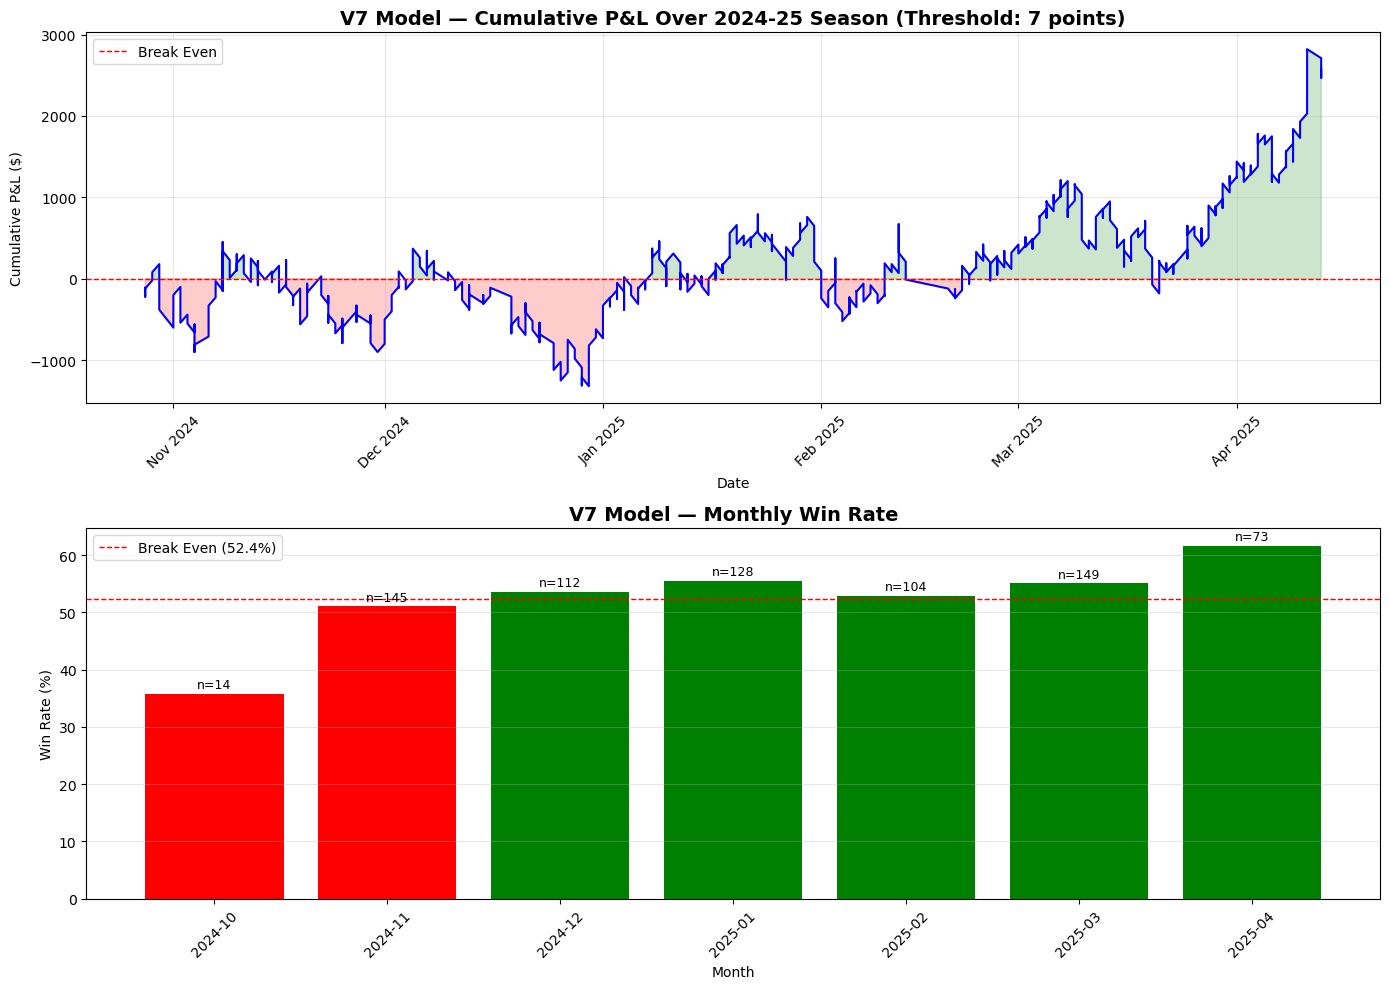

Chart saved to Downloads folder


In [45]:
# ============================================================
# STEP 40: VISUALIZE V7 P&L OVER TIME
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use threshold 7 since that's our best for V7
BEST_THRESHOLD_V7 = 7

# Get the games we would have bet on
bet_games_v7 = merged_v7[abs(merged_v7['SIGNAL_V7']) >= BEST_THRESHOLD_V7].copy()
bet_games_v7 = bet_games_v7.sort_values('HOME_GAME_DATE').reset_index(drop=True)

# Calculate win/loss for each bet
bet_games_v7['WON'] = bet_games_v7.apply(did_we_win, axis=1)

# Running P&L
bet_games_v7['GAME_PNL'] = bet_games_v7['WON'].apply(lambda x: WIN_PAYOUT if x else -LOSS_COST)
bet_games_v7['CUMULATIVE_PNL'] = bet_games_v7['GAME_PNL'].cumsum()

# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Chart 1: Cumulative P&L over the season ---
axes[0].plot(bet_games_v7['HOME_GAME_DATE'], bet_games_v7['CUMULATIVE_PNL'],
             color='blue', linewidth=1.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, label='Break Even')
axes[0].fill_between(bet_games_v7['HOME_GAME_DATE'], bet_games_v7['CUMULATIVE_PNL'], 0,
                     where=bet_games_v7['CUMULATIVE_PNL'] >= 0, alpha=0.2, color='green')
axes[0].fill_between(bet_games_v7['HOME_GAME_DATE'], bet_games_v7['CUMULATIVE_PNL'], 0,
                     where=bet_games_v7['CUMULATIVE_PNL'] < 0, alpha=0.2, color='red')
axes[0].set_title(f'V7 Model — Cumulative P&L Over 2024-25 Season (Threshold: {BEST_THRESHOLD_V7} points)',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)
axes[0].grid(True, alpha=0.3)

# --- Chart 2: Monthly win rate ---
bet_games_v7['MONTH'] = bet_games_v7['HOME_GAME_DATE'].dt.to_period('M')
monthly_v7 = bet_games_v7.groupby('MONTH').agg(
    win_rate=('WON', 'mean'),
    num_bets=('WON', 'count')
).reset_index()
monthly_v7['MONTH_STR'] = monthly_v7['MONTH'].astype(str)

bars = axes[1].bar(monthly_v7['MONTH_STR'], monthly_v7['win_rate'] * 100,
                   color=['green' if x > 52.4 else 'red' for x in monthly_v7['win_rate'] * 100])
axes[1].axhline(y=52.4, color='red', linestyle='--', linewidth=1, label='Break Even (52.4%)')
axes[1].set_title('V7 Model — Monthly Win Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Win Rate (%)')
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Add bet count labels on bars
for bar, row in zip(bars, monthly_v7.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'n={row.num_bets}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/jkramer24/Downloads/nba_v7_backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Downloads folder")

In [47]:
# ============================================================
# STEP 41: CALCULATE PACE FROM EXISTING DATA
# ============================================================

# Pace formula (simplified):
# Possessions ≈ FGA - OREB + TOV + (0.44 * FTA)
# We already have all these columns in our original df

# Calculate possessions for each team per game
df['POSSESSIONS'] = (
    df['FGA'] - df['OREB'] + df['TOV'] + (0.44 * df['FTA'])
)

# Rolling average pace over last 10 games
df['ROLL_PACE'] = (
    df.groupby('TEAM_ID')['POSSESSIONS']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

print("Pace calculated successfully")
print(f"\nAverage possessions per game: {df['POSSESSIONS'].mean():.1f}")
print(f"\nSample:")
df[['TEAM_ABBREVIATION', 'GAME_DATE', 'POSSESSIONS', 'ROLL_PACE']].dropna().head(10)

Pace calculated successfully

Average possessions per game: 101.1

Sample:


,TEAM_ABBREVIATION,GAME_DATE,POSSESSIONS,ROLL_PACE
3,ATL,2020-12-30,109.40,104.853333
4,ATL,2021-01-01,98.16,105.990000
5,ATL,2021-01-02,98.36,104.424000
6,ATL,2021-01-04,99.12,103.413333
7,ATL,2021-01-06,104.92,102.800000
8,ATL,2021-01-09,98.32,103.065000
9,ATL,2021-01-11,104.88,102.537778
10,ATL,2021-01-15,105.60,102.772000
11,ATL,2021-01-16,105.32,102.756000
12,ATL,2021-01-18,107.00,102.516000


In [49]:
# ============================================================
# STEP 42: BUILD PACE MISMATCH FEATURE AND RETRAIN
# ============================================================

# Build team features with pace
team_features_pace = df[[
    'GAME_ID', 'TEAM_ID', 'ROLL_PACE'
]].copy()

# Merge onto games_v4 (our best model base)
games_v8 = pd.merge(
    games_v4,
    team_features_pace.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_PACE': 'HOME_ROLL_PACE'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

games_v8 = pd.merge(
    games_v8,
    team_features_pace.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_PACE': 'AWAY_ROLL_PACE'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# Pace mismatch = absolute difference in pace between the two teams
# A big mismatch means one team wants to play fast, the other slow
# This creates unpredictability that Vegas may not fully price
games_v8['PACE_MISMATCH'] = abs(games_v8['HOME_ROLL_PACE'] - games_v8['AWAY_ROLL_PACE'])

# Also add travel fatigue since that's already in V7
games_v8['HOME_TZ'] = games_v8['HOME_TEAM_ABBREVIATION'].map(team_timezones)
games_v8['AWAY_TZ'] = games_v8['AWAY_TEAM_ABBREVIATION'].map(team_timezones)
games_v8['TRAVEL_FATIGUE'] = games_v8['HOME_TZ'] - games_v8['AWAY_TZ']

games_v8 = games_v8.dropna(subset=['HOME_ROLL_PACE', 'AWAY_ROLL_PACE'])
print(f"Games with pace feature: {len(games_v8)}")

# Define v8 feature set — V7 + pace mismatch
features_v8 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'HOME_TEAM_HCS',
    'AWAY_TEAM_HCS',
    'TRAVEL_FATIGUE',
    'HOME_ROLL_PACE',
    'AWAY_ROLL_PACE',
    'PACE_MISMATCH'
]

# Train/val split
train_v8 = games_v8[games_v8['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_v8   = games_v8[games_v8['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games: {len(train_v8)}")
print(f"Validation games: {len(val_v8)}")

# Train model
model_v8 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v8.fit(train_v8[features_v8], train_v8['POINT_DIFF'])

# Validate
val_preds_v8 = model_v8.predict(val_v8[features_v8])
mae_v8 = mean_absolute_error(val_v8['POINT_DIFF'], val_preds_v8)
print(f"\nV8 model MAE: {mae_v8:.2f} points")
print(f"V7 model MAE: 11.46 points")
print(f"Original model MAE: 11.45 points")

# Feature importance
importance_v8 = pd.DataFrame({
    'feature': features_v8,
    'importance': model_v8.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v8.to_string(index=False))

Games with pace feature: 4675
Training games: 3460
Validation games: 1215

V8 model MAE: 11.42 points
V7 model MAE: 11.46 points
Original model MAE: 11.45 points

Feature importance:
       feature  importance
 HOME_TEAM_HCS    0.120467
 HOME_ROLL_DEF    0.113165
 HOME_ROLL_OFF    0.102532
 AWAY_ROLL_DEF    0.093523
 AWAY_ROLL_OFF    0.093481
AWAY_ROLL_PACE    0.082577
AWAY_DAYS_REST    0.073190
HOME_ROLL_PACE    0.071600
 AWAY_TEAM_HCS    0.070482
HOME_DAYS_REST    0.061692
 PACE_MISMATCH    0.059205
TRAVEL_FATIGUE    0.058085


In [51]:
# ============================================================
# STEP 43: RUN V8 BACKTEST
# ============================================================

# Add pace to 2024-25 data
df_2425['POSSESSIONS'] = (
    df_2425['FGA'] - df_2425['OREB'] + df_2425['TOV'] + (0.44 * df_2425['FTA'])
)

df_2425['ROLL_PACE'] = (
    df_2425.groupby('TEAM_ID')['POSSESSIONS']
    .transform(lambda x: x.rolling(10, min_periods=3).mean().shift(1))
)

team_features_2425_pace = df_2425[[
    'GAME_ID', 'TEAM_ID', 'ROLL_PACE'
]].copy()

# Merge onto merged_v7
merged_v8 = pd.merge(
    merged_v7,
    team_features_2425_pace.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'ROLL_PACE': 'HOME_ROLL_PACE'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

merged_v8 = pd.merge(
    merged_v8,
    team_features_2425_pace.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROLL_PACE': 'AWAY_ROLL_PACE'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

merged_v8['PACE_MISMATCH'] = abs(merged_v8['HOME_ROLL_PACE'] - merged_v8['AWAY_ROLL_PACE'])
merged_v8 = merged_v8.dropna(subset=['HOME_ROLL_PACE', 'AWAY_ROLL_PACE'])

print(f"Games for V8 backtest: {len(merged_v8)}")

# Run predictions
merged_v8['MODEL_PRED_V8'] = model_v8.predict(merged_v8[features_v8])
merged_v8['SIGNAL_V8'] = merged_v8['MODEL_PRED_V8'] - merged_v8['VEGAS_LINE']

results_v8 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_v8[abs(merged_v8['SIGNAL_V8']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v8.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV8 Model (V7 + pace):")
print(pd.DataFrame(results_v8).to_string(index=False))
print("\nV7 Model - current best:")
print("""
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   540     522    50.8% $-3,420
         3   991   503     488    50.8% $-3,380
         4   928   476     452    51.3% $-2,120
         5   861   443     418    51.5% $-1,680
         6   797   416     381    52.2%   $-310
         7   725   392     333    54.1%  $2,570
         8   658   350     308    53.2%  $1,120
        10   511   271     240    53.0%    $700""")

Games for V8 backtest: 1177

V8 Model (V7 + pace):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1068   541     527    50.7% $-3,870
         3   997   508     489    51.0% $-2,990
         4   928   485     443    52.3%   $-230
         5   869   454     415    52.2%   $-250
         6   791   414     377    52.3%    $-70
         7   712   371     341    52.1%   $-410
         8   647   337     310    52.1%   $-400
        10   511   274     237    53.6%  $1,330

V7 Model - current best:

 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   540     522    50.8% $-3,420
         3   991   503     488    50.8% $-3,380
         4   928   476     452    51.3% $-2,120
         5   861   443     418    51.5% $-1,680
         6   797   416     381    52.2%   $-310
         7   725   392     333    54.1%  $2,570
         8   658   350     308    53.2%  $1,120
        10   511   271     240    53.0%    $700


In [53]:
# ============================================================
# STEP 44: ADD STREAK LENGTH FEATURE
# ============================================================

# Streak length = how many games in a row has a team won or lost
# Positive number = winning streak (e.g. 5 = won last 5)
# Negative number = losing streak (e.g. -4 = lost last 4)
# This is different from win percentage — a team on a 7 game win streak
# plays with different energy than a team that won 7 of their last 10

def calculate_streak(wins):
    streaks = []
    current_streak = 0
    for w in wins:
        if w == 1:
            current_streak = current_streak + 1 if current_streak > 0 else 1
        else:
            current_streak = current_streak - 1 if current_streak < 0 else -1
        streaks.append(current_streak)
    return streaks

# Apply streak calculation per team
# shift(1) so we don't include the current game
df['STREAK'] = (
    df.groupby('TEAM_ID')['WIN']
    .transform(lambda x: pd.Series(calculate_streak(x.tolist()), index=x.index).shift(1))
)

print("Streak calculated successfully")
print(f"\nStreak distribution:")
print(df['STREAK'].value_counts().sort_index().head(20))
print(f"\nSample:")
df[['TEAM_ABBREVIATION', 'GAME_DATE', 'WIN', 'STREAK']].dropna().head(15)

Streak calculated successfully

Streak distribution:
STREAK
-28.0     1
-27.0     1
-26.0     1
-25.0     1
-24.0     1
-23.0     1
-22.0     1
-21.0     1
-20.0     2
-19.0     2
-18.0     3
-17.0     3
-16.0     5
-15.0     7
-14.0     9
-13.0    11
-12.0    13
-11.0    21
-10.0    29
-9.0     42
Name: count, dtype: int64

Sample:


,TEAM_ABBREVIATION,GAME_DATE,WIN,STREAK
1,ATL,2020-12-26,1,1.0
2,ATL,2020-12-28,1,2.0
3,ATL,2020-12-30,0,3.0
4,ATL,2021-01-01,1,-1.0
5,ATL,2021-01-02,0,1.0
6,ATL,2021-01-04,0,-1.0
7,ATL,2021-01-06,0,-2.0
8,ATL,2021-01-09,0,-3.0
9,ATL,2021-01-11,1,-4.0
10,ATL,2021-01-15,0,1.0


In [55]:
# ============================================================
# STEP 45: MERGE STREAK INTO MODEL AND RETRAIN
# ============================================================

team_features_streak = df[['GAME_ID', 'TEAM_ID', 'STREAK']].copy()

# Merge onto games_v4 (V7 base)
games_v9 = pd.merge(
    games_v4,
    team_features_streak.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'STREAK': 'HOME_STREAK'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

games_v9 = pd.merge(
    games_v9,
    team_features_streak.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'STREAK': 'AWAY_STREAK'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# Streak advantage — home team streak minus away team streak
games_v9['STREAK_ADVANTAGE'] = games_v9['HOME_STREAK'] - games_v9['AWAY_STREAK']

# Add travel fatigue
games_v9['HOME_TZ'] = games_v9['HOME_TEAM_ABBREVIATION'].map(team_timezones)
games_v9['AWAY_TZ'] = games_v9['AWAY_TEAM_ABBREVIATION'].map(team_timezones)
games_v9['TRAVEL_FATIGUE'] = games_v9['HOME_TZ'] - games_v9['AWAY_TZ']

games_v9 = games_v9.dropna(subset=['HOME_STREAK', 'AWAY_STREAK'])
print(f"Games with streak feature: {len(games_v9)}")

# V9 feature set — V7 + streak
features_v9 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'HOME_TEAM_HCS',
    'AWAY_TEAM_HCS',
    'TRAVEL_FATIGUE',
    'HOME_STREAK',
    'AWAY_STREAK',
    'STREAK_ADVANTAGE'
]

train_v9 = games_v9[games_v9['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_v9   = games_v9[games_v9['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games: {len(train_v9)}")
print(f"Validation games: {len(val_v9)}")

model_v9 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v9.fit(train_v9[features_v9], train_v9['POINT_DIFF'])

val_preds_v9 = model_v9.predict(val_v9[features_v9])
mae_v9 = mean_absolute_error(val_v9['POINT_DIFF'], val_preds_v9)
print(f"\nV9 model MAE: {mae_v9:.2f} points")
print(f"V7 model MAE: 11.46 points")
print(f"Original model MAE: 11.45 points")

importance_v9 = pd.DataFrame({
    'feature': features_v9,
    'importance': model_v9.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v9.to_string(index=False))

Games with streak feature: 4675
Training games: 3460
Validation games: 1215

V9 model MAE: 11.60 points
V7 model MAE: 11.46 points
Original model MAE: 11.45 points

Feature importance:
         feature  importance
STREAK_ADVANTAGE    0.170690
   HOME_TEAM_HCS    0.107699
   HOME_ROLL_DEF    0.104391
   HOME_ROLL_OFF    0.092189
   AWAY_ROLL_DEF    0.087422
   AWAY_ROLL_OFF    0.077604
   AWAY_TEAM_HCS    0.068453
  AWAY_DAYS_REST    0.067002
  HOME_DAYS_REST    0.061320
     AWAY_STREAK    0.059490
  TRAVEL_FATIGUE    0.055521
     HOME_STREAK    0.048221


In [57]:
# ============================================================
# STEP 46: RUN V9 BACKTEST
# ============================================================

# Add streak to 2024-25 data
df_2425['STREAK'] = (
    df_2425.groupby('TEAM_ID')['WIN']
    .transform(lambda x: pd.Series(calculate_streak(x.tolist()), index=x.index).shift(1))
)

team_features_2425_streak = df_2425[['GAME_ID', 'TEAM_ID', 'STREAK']].copy()

# Merge onto merged_v7
merged_v9 = pd.merge(
    merged_v7,
    team_features_2425_streak.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'STREAK': 'HOME_STREAK'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

merged_v9 = pd.merge(
    merged_v9,
    team_features_2425_streak.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'STREAK': 'AWAY_STREAK'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

merged_v9['STREAK_ADVANTAGE'] = merged_v9['HOME_STREAK'] - merged_v9['AWAY_STREAK']
merged_v9 = merged_v9.dropna(subset=['HOME_STREAK', 'AWAY_STREAK'])

print(f"Games for V9 backtest: {len(merged_v9)}")

# Run predictions
merged_v9['MODEL_PRED_V9'] = model_v9.predict(merged_v9[features_v9])
merged_v9['SIGNAL_V9'] = merged_v9['MODEL_PRED_V9'] - merged_v9['VEGAS_LINE']

results_v9 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_v9[abs(merged_v9['SIGNAL_V9']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v9.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV9 Model (V7 + streak):")
print(pd.DataFrame(results_v9).to_string(index=False))
print("\nV7 Model - current best:")
print("""
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   540     522    50.8% $-3,420
         3   991   503     488    50.8% $-3,380
         4   928   476     452    51.3% $-2,120
         5   861   443     418    51.5% $-1,680
         6   797   416     381    52.2%   $-310
         7   725   392     333    54.1%  $2,570
         8   658   350     308    53.2%  $1,120
        10   511   271     240    53.0%    $700""")

Games for V9 backtest: 1177

V9 Model (V7 + streak):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1056   537     519    50.9% $-3,390
         3   989   501     488    50.7% $-3,580
         4   913   467     446    51.2% $-2,360
         5   850   437     413    51.4% $-1,730
         6   783   411     372    52.5%    $180
         7   713   380     333    53.3%  $1,370
         8   657   347     310    52.8%    $600
        10   488   255     233    52.3%   $-130

V7 Model - current best:

 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   540     522    50.8% $-3,420
         3   991   503     488    50.8% $-3,380
         4   928   476     452    51.3% $-2,120
         5   861   443     418    51.5% $-1,680
         6   797   416     381    52.2%   $-310
         7   725   392     333    54.1%  $2,570
         8   658   350     308    53.2%  $1,120
        10   511   271     240    53.0%    $700


In [59]:
# ============================================================
# STEP 47: CURRENT SEASON HOME/ROAD RECORD
# ============================================================

# Calculate each team's current season home win % and road win %
# This is more responsive than the 4-season historical average
# A team that was great at home 3 years ago but is bad at home now
# would be better captured by current season splits

# Home win percentage this season so far
home_games_split = df[df['MATCHUP'].str.contains('vs.')].copy()
away_games_split = df[df['MATCHUP'].str.contains('@')].copy()

# Rolling home win percentage — cumulative this season
home_games_split = home_games_split.sort_values(['TEAM_ID', 'GAME_DATE'])
home_games_split['HOME_WIN_THIS_SEASON'] = (
    home_games_split.groupby(['TEAM_ID', 'SEASON_ID'])['WIN']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Rolling road win percentage — cumulative this season
away_games_split = away_games_split.sort_values(['TEAM_ID', 'GAME_DATE'])
away_games_split['ROAD_WIN_THIS_SEASON'] = (
    away_games_split.groupby(['TEAM_ID', 'SEASON_ID'])['WIN']
    .transform(lambda x: x.shift(1).expanding().mean())
)

print("Home/road splits calculated")
print(f"\nSample home splits:")
home_games_split[['TEAM_ABBREVIATION', 'GAME_DATE', 'WIN', 'HOME_WIN_THIS_SEASON']].dropna().head(10)

Home/road splits calculated

Sample home splits:


,TEAM_ABBREVIATION,GAME_DATE,WIN,HOME_WIN_THIS_SEASON
5,ATL,2021-01-02,0,1.000000
6,ATL,2021-01-04,0,0.500000
7,ATL,2021-01-06,0,0.333333
9,ATL,2021-01-11,1,0.250000
12,ATL,2021-01-18,1,0.400000
13,ATL,2021-01-20,1,0.500000
16,ATL,2021-01-26,1,0.571429
17,ATL,2021-01-27,0,0.625000
19,ATL,2021-02-01,0,0.555556
20,ATL,2021-02-03,0,0.500000


In [61]:
# ============================================================
# STEP 48: MERGE HOME/ROAD SPLITS AND RETRAIN
# ============================================================

# Pull just the columns we need
home_split_features = home_games_split[['GAME_ID', 'TEAM_ID', 'HOME_WIN_THIS_SEASON']].copy()
road_split_features = away_games_split[['GAME_ID', 'TEAM_ID', 'ROAD_WIN_THIS_SEASON']].copy()

# Merge onto games_v4 (V7 base)
games_v10 = pd.merge(
    games_v4,
    home_split_features.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'HOME_WIN_THIS_SEASON': 'HOME_TEAM_HOME_WINPCT'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

games_v10 = pd.merge(
    games_v10,
    road_split_features.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROAD_WIN_THIS_SEASON': 'AWAY_TEAM_ROAD_WINPCT'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

# Add travel fatigue
games_v10['HOME_TZ'] = games_v10['HOME_TEAM_ABBREVIATION'].map(team_timezones)
games_v10['AWAY_TZ'] = games_v10['AWAY_TEAM_ABBREVIATION'].map(team_timezones)
games_v10['TRAVEL_FATIGUE'] = games_v10['HOME_TZ'] - games_v10['AWAY_TZ']

games_v10 = games_v10.dropna(subset=['HOME_TEAM_HOME_WINPCT', 'AWAY_TEAM_ROAD_WINPCT'])
print(f"Games with home/road splits: {len(games_v10)}")

# V10 feature set — V7 + current season home/road splits
features_v10 = [
    'HOME_ROLL_OFF',
    'HOME_ROLL_DEF',
    'AWAY_ROLL_OFF',
    'AWAY_ROLL_DEF',
    'HOME_DAYS_REST',
    'AWAY_DAYS_REST',
    'HOME_TEAM_HCS',
    'AWAY_TEAM_HCS',
    'TRAVEL_FATIGUE',
    'HOME_TEAM_HOME_WINPCT',
    'AWAY_TEAM_ROAD_WINPCT'
]

train_v10 = games_v10[games_v10['HOME_GAME_DATE'] < '2023-10-01'].copy()
val_v10   = games_v10[games_v10['HOME_GAME_DATE'] >= '2023-10-01'].copy()

print(f"Training games: {len(train_v10)}")
print(f"Validation games: {len(val_v10)}")

model_v10 = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_v10.fit(train_v10[features_v10], train_v10['POINT_DIFF'])

val_preds_v10 = model_v10.predict(val_v10[features_v10])
mae_v10 = mean_absolute_error(val_v10['POINT_DIFF'], val_preds_v10)
print(f"\nV10 model MAE: {mae_v10:.2f} points")
print(f"V7 model MAE: 11.46 points")
print(f"Original model MAE: 11.45 points")

importance_v10 = pd.DataFrame({
    'feature': features_v10,
    'importance': model_v10.feature_importances_
}).sort_values('importance', ascending=False)
print(f"\nFeature importance:")
print(importance_v10.to_string(index=False))

Games with home/road splits: 4604
Training games: 3411
Validation games: 1193

V10 model MAE: 11.36 points
V7 model MAE: 11.46 points
Original model MAE: 11.45 points

Feature importance:
              feature  importance
HOME_TEAM_HOME_WINPCT    0.199234
AWAY_TEAM_ROAD_WINPCT    0.122037
        HOME_TEAM_HCS    0.096809
        HOME_ROLL_DEF    0.083322
        AWAY_ROLL_DEF    0.080773
        AWAY_ROLL_OFF    0.077644
       HOME_DAYS_REST    0.077204
        HOME_ROLL_OFF    0.072945
        AWAY_TEAM_HCS    0.064464
       TRAVEL_FATIGUE    0.063533
       AWAY_DAYS_REST    0.062036


In [63]:
# ============================================================
# STEP 49: RUN V10 BACKTEST
# ============================================================

# Add home/road splits to 2024-25 data
home_games_2425_split = df_2425[df_2425['MATCHUP'].str.contains('vs.')].copy()
away_games_2425_split = df_2425[df_2425['MATCHUP'].str.contains('@')].copy()

home_games_2425_split = home_games_2425_split.sort_values(['TEAM_ID', 'GAME_DATE'])
home_games_2425_split['HOME_WIN_THIS_SEASON'] = (
    home_games_2425_split.groupby(['TEAM_ID', 'SEASON_ID'])['WIN']
    .transform(lambda x: x.shift(1).expanding().mean())
)

away_games_2425_split = away_games_2425_split.sort_values(['TEAM_ID', 'GAME_DATE'])
away_games_2425_split['ROAD_WIN_THIS_SEASON'] = (
    away_games_2425_split.groupby(['TEAM_ID', 'SEASON_ID'])['WIN']
    .transform(lambda x: x.shift(1).expanding().mean())
)

home_split_2425 = home_games_2425_split[['GAME_ID', 'TEAM_ID', 'HOME_WIN_THIS_SEASON']].copy()
road_split_2425 = away_games_2425_split[['GAME_ID', 'TEAM_ID', 'ROAD_WIN_THIS_SEASON']].copy()

# Merge onto merged_v7
merged_v10 = pd.merge(
    merged_v7,
    home_split_2425.rename(columns={
        'TEAM_ID': 'HOME_TEAM_ID',
        'HOME_WIN_THIS_SEASON': 'HOME_TEAM_HOME_WINPCT'
    }),
    on=['GAME_ID', 'HOME_TEAM_ID']
)

merged_v10 = pd.merge(
    merged_v10,
    road_split_2425.rename(columns={
        'TEAM_ID': 'AWAY_TEAM_ID',
        'ROAD_WIN_THIS_SEASON': 'AWAY_TEAM_ROAD_WINPCT'
    }),
    on=['GAME_ID', 'AWAY_TEAM_ID']
)

merged_v10 = merged_v10.dropna(subset=['HOME_TEAM_HOME_WINPCT', 'AWAY_TEAM_ROAD_WINPCT'])
print(f"Games for V10 backtest: {len(merged_v10)}")

# Run predictions
merged_v10['MODEL_PRED_V10'] = model_v10.predict(merged_v10[features_v10])
merged_v10['SIGNAL_V10'] = merged_v10['MODEL_PRED_V10'] - merged_v10['VEGAS_LINE']

results_v10 = []

for threshold in [2, 3, 4, 5, 6, 7, 8, 10]:
    bet_games = merged_v10[abs(merged_v10['SIGNAL_V10']) >= threshold].copy()
    if len(bet_games) == 0:
        continue

    bet_games['WON'] = bet_games.apply(did_we_win, axis=1)
    wins = bet_games['WON'].sum()
    losses = len(bet_games) - wins
    pnl = (wins * WIN_PAYOUT) - (losses * LOSS_COST)
    win_rate = wins / len(bet_games) * 100

    results_v10.append({
        'Threshold': threshold,
        'Bets': len(bet_games),
        'Wins': wins,
        'Losses': losses,
        'Win Rate': f"{win_rate:.1f}%",
        'P&L': f"${pnl:,.0f}"
    })

print("\nV10 Model (V7 + home/road splits):")
print(pd.DataFrame(results_v10).to_string(index=False))
print("\nV7 Model - current best:")
print("""
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   540     522    50.8% $-3,420
         3   991   503     488    50.8% $-3,380
         4   928   476     452    51.3% $-2,120
         5   861   443     418    51.5% $-1,680
         6   797   416     381    52.2%   $-310
         7   725   392     333    54.1%  $2,570
         8   658   350     308    53.2%  $1,120
        10   511   271     240    53.0%    $700""")

Games for V10 backtest: 1176

V10 Model (V7 + home/road splits):
 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1067   539     528    50.5% $-4,180
         3  1015   510     505    50.2% $-4,550
         4   957   483     474    50.5% $-3,840
         5   882   453     429    51.4% $-1,890
         6   815   424     391    52.0%   $-610
         7   752   392     360    52.1%   $-400
         8   682   354     328    51.9%   $-680
        10   538   282     256    52.4%     $40

V7 Model - current best:

 Threshold  Bets  Wins  Losses Win Rate     P&L
         2  1062   540     522    50.8% $-3,420
         3   991   503     488    50.8% $-3,380
         4   928   476     452    51.3% $-2,120
         5   861   443     418    51.5% $-1,680
         6   797   416     381    52.2%   $-310
         7   725   392     333    54.1%  $2,570
         8   658   350     308    53.2%  $1,120
        10   511   271     240    53.0%    $700


In [65]:
# ============================================================
# SAVE NBA GAME-BY-GAME P&L
# ============================================================

# Get the games we bet on at threshold 7 using V7 model
nba_bets = merged_v7[abs(merged_v7['SIGNAL_V7']) >= 7].copy()
nba_bets['WON'] = nba_bets.apply(did_we_win, axis=1)
nba_bets['GAME_PNL'] = nba_bets['WON'].apply(lambda x: 100 if x else -110)

# Keep only what we need
nba_pnl = nba_bets[['HOME_GAME_DATE', 'HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'GAME_PNL']].copy()
nba_pnl.columns = ['date', 'home', 'away', 'NBA_PNL']
nba_pnl['date'] = pd.to_datetime(nba_pnl['date'])

# Save to Downloads
nba_pnl.to_csv('/Users/jkramer24/Downloads/nba_pnl.csv', index=False)
print(f"NBA P&L saved: {len(nba_pnl)} bets")
print(f"Total NBA profit: ${nba_pnl['NBA_PNL'].sum():,.0f}")
print(f"\nSample:")
nba_pnl.head()

NBA P&L saved: 725 bets
Total NBA profit: $2,570

Sample:


,date,home,away,NBA_PNL
1,2024-11-04,ATL,BOS,100
4,2024-11-15,ATL,WAS,100
7,2024-12-02,ATL,NOP,100
8,2024-12-06,ATL,LAL,-110
16,2025-01-23,ATL,TOR,-110
